# 02 — Clinical EDA

**Sections**
1. Dataset overview — completeness table + outlier detection
2. Population characterization — distributions for every variable group
3. Risk factors
4. Scar geometry (detailed, with variable glossary)
5. Echocardiography (with variable glossary)
6. Correlation matrix — all numeric variables
7. Subgroup comparisons
8. Devices
9. Arrhythmias
10. Medications
11. Outcomes

## 0 · Setup

In [1]:
import json
import sys
from math import ceil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats

MODULE_DIR = Path('..').resolve()
if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))
from src.clinical_data import load, COLUMN_GROUPS
from src.data_loading import scan

CSV_PATH = Path('C:/Users/joan/Desktop/FEINA/UPF/TFG/develop-vt.csv')
HD_ROOT = Path('F:/RM_TEKNON_DEVELOP')
RESULTS_DIR = MODULE_DIR / 'results'
RESULTS_DIR.mkdir(exist_ok=True)
SPLIT_JSON = MODULE_DIR / 'results' / 'split.json'

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10,
})
PAL = plt.cm.tab10.colors
HIST_COLOR = '#4C78A8'
SEG_COLOR = '#F28E2B'
NO_SEG_COLOR = '#4C78A8'

VARIABLE_INFO = {
    'age': ('Age (years)', 'Patient age at the time of MRI'),
    'sex': ('Sex', 'Registry code: 1 = male, 2 = female'),
    'mi_to_mri_months': ('Delay from MI to MRI (months)', 'Months between infarction and MRI'),
    'lv_mass_g': ('LV mass (g)', 'Left ventricular myocardial mass in grams'),
    'bz_core_g': ('Total scar mass (g)', 'Border zone + core scar mass in grams'),
    'bz_core_pct': ('Total scar (% LV mass)', 'Border zone + core scar as a percentage of LV mass'),
    'bz_g': ('Border-zone mass (g)', 'Heterogeneous border zone mass in grams'),
    'bz_pct': ('Border zone (% LV mass)', 'Border zone as a percentage of LV mass'),
    'core_g': ('Core scar mass (g)', 'Dense core scar mass in grams'),
    'core_pct': ('Core scar (% LV mass)', 'Dense core scar as a percentage of LV mass'),
    'channel_mass_g': ('Channel mass (g)', 'Mass of identified conduction channels inside the scar'),
    'lvef_pct': ('LVEF (%)', 'Left ventricular ejection fraction'),
    'lvedd_mm': ('LV end-diastolic diameter (mm)', 'Diastolic LV diameter'),
    'lvesd_mm': ('LV end-systolic diameter (mm)', 'Systolic LV diameter'),
    'lvedv_ml': ('LV end-diastolic volume (mL)', 'LV volume at end-diastole'),
    'lvedv_index': ('LV end-diastolic volume index', 'Indexed LV end-diastolic volume'),
    'lvesv_ml': ('LV end-systolic volume (mL)', 'LV volume at end-systole'),
    'lvesv_index': ('LV end-systolic volume index', 'Indexed LV end-systolic volume'),
    'la_mm': ('Left atrial diameter (mm)', 'Left atrial size'),
    'septum_mm': ('Septum thickness (mm)', 'Interventricular septum thickness'),
    'post_wall_mm': ('Posterior wall thickness (mm)', 'Posterior LV wall thickness'),
    'enhancement_territory': ('Enhancement territory', 'Main coronary territory with scar'),
    'enhancement_distribution': ('Enhancement distribution', 'Scar distribution pattern across the wall'),
    'enhancement_grade': ('Enhancement grade', 'Semiquantitative enhancement extent/intensity score'),
    'channels': ('Channels', '1 = conduction channels identified within the scar'),
    'mri_type': ('MRI type', 'Acquisition / MRI study type recorded in the registry'),
    'has_segmentation': ('Has MRI segmentation', 'Patient has an ADAS3D scar segmentation available'),
}


def variable_label(col):
    return VARIABLE_INFO.get(col, (col.replace('_', ' ').title(), ''))[0]


def variable_description(col):
    return VARIABLE_INFO.get(col, (col.replace('_', ' ').title(), ''))[1]


def variable_title(col):
    desc = variable_description(col)
    if desc:
        return f"{variable_label(col)}\n{desc}"
    return variable_label(col)


def normalize_patient_id(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    if text.endswith('.0'):
        text = text[:-2]
    return text


def zscore(series):
    s = pd.to_numeric(series, errors='coerce')
    std = s.std()
    if pd.isna(std) or std == 0:
        return s * np.nan
    return (s - s.mean()) / std


df = load(CSV_PATH)
df['patient_id_norm'] = df['patient_id'].map(normalize_patient_id)
print(f'Loaded: {len(df)} patients, {len(df.columns)} columns')


Loaded: 173 patients, 87 columns


In [2]:
# Identify patients that have MRI segmentation from the real ADAS3D scan used in 01_scar_exploration.
def has_core_segmentation(case):
    p = case.tissue_surfaces.get('core')
    return p is not None and p.exists()

if HD_ROOT.exists():
    all_cases = scan(HD_ROOT)
    seg_ids = {normalize_patient_id(case.patient_id) for case in all_cases if has_core_segmentation(case)}
    print('Segmentation source: full ADAS3D scan (same criterion as 01_scar_exploration)')
elif SPLIT_JSON.exists():
    with open(SPLIT_JSON) as f:
        split = json.load(f)
    seg_ids = {normalize_patient_id(pid.split('/')[-1])
               for pid in split.get('known', []) + split.get('held_out', [])}
    print('Segmentation source: split.json fallback')
else:
    seg_ids = set()
    print('No segmentation source found - has_segmentation set to False for all rows')

df['has_segmentation'] = df['patient_id_norm'].isin(seg_ids)

n_seg = int(df['has_segmentation'].sum())
print(f'Patients with MRI segmentation: {n_seg} / {len(df)}')
print(df['has_segmentation'].value_counts())



Segmentation source: split.json fallback
Patients with MRI segmentation: 88 / 173
has_segmentation
True     88
False    85
Name: count, dtype: int64


## 1 · Dataset overview

Printed table only — no heatmap.
Shows dtype, n valid, % missing, n unique, and for numeric columns: mean, std, min, max.

In [3]:
rows = []
for col in df.columns:
    s = df[col]
    row = {
        'column':      col,
        'dtype':       str(s.dtype),
        'n_valid':     int(s.notna().sum()),
        'pct_missing': round(s.isna().mean() * 100, 1),
        'n_unique':    int(s.nunique()),
    }
    if pd.api.types.is_numeric_dtype(s) and s.notna().sum() > 0:
        row['mean'] = round(float(s.mean()), 2)
        row['std']  = round(float(s.std()),  2)
        row['min']  = float(s.min())
        row['max']  = float(s.max())
    rows.append(row)

overview = pd.DataFrame(rows).set_index('column')
pd.set_option('display.max_rows', 120)
display(overview)

,dtype,n_valid,pct_missing,n_unique,mean,std,min,max
column,,,,,,,,
inclusion,str,128,26.0,42,NaN,NaN,NaN,NaN
patient_id,str,171,1.2,171,NaN,NaN,NaN,NaN
date_mi,datetime64[us],54,68.8,47,NaN,NaN,NaN,NaN
date_mri,datetime64[us],136,21.4,128,NaN,NaN,NaN,NaN
mri_type,str,159,8.1,10,NaN,NaN,NaN,NaN
diagnosis,str,162,6.4,9,NaN,NaN,NaN,NaN
lv_mass_g,float64,166,4.0,165,120.24,36.82,55.54,283.25
bz_core_g,float64,166,4.0,160,16.64,14.14,1.04,106.50
bz_core_pct,float64,166,4.0,160,13.05,8.02,1.42,51.50


### 1b ? Numeric outlier check ? scatter vs patient row index

Each point is one patient.
- **X axis** = patient row index in the clinical registry.
- **Y axis** = raw value of the variable shown in the panel.
- **Orange** = patient has MRI segmentation, **blue** = no segmentation.

Points far from the main cloud are possible outliers or data-entry values to review.


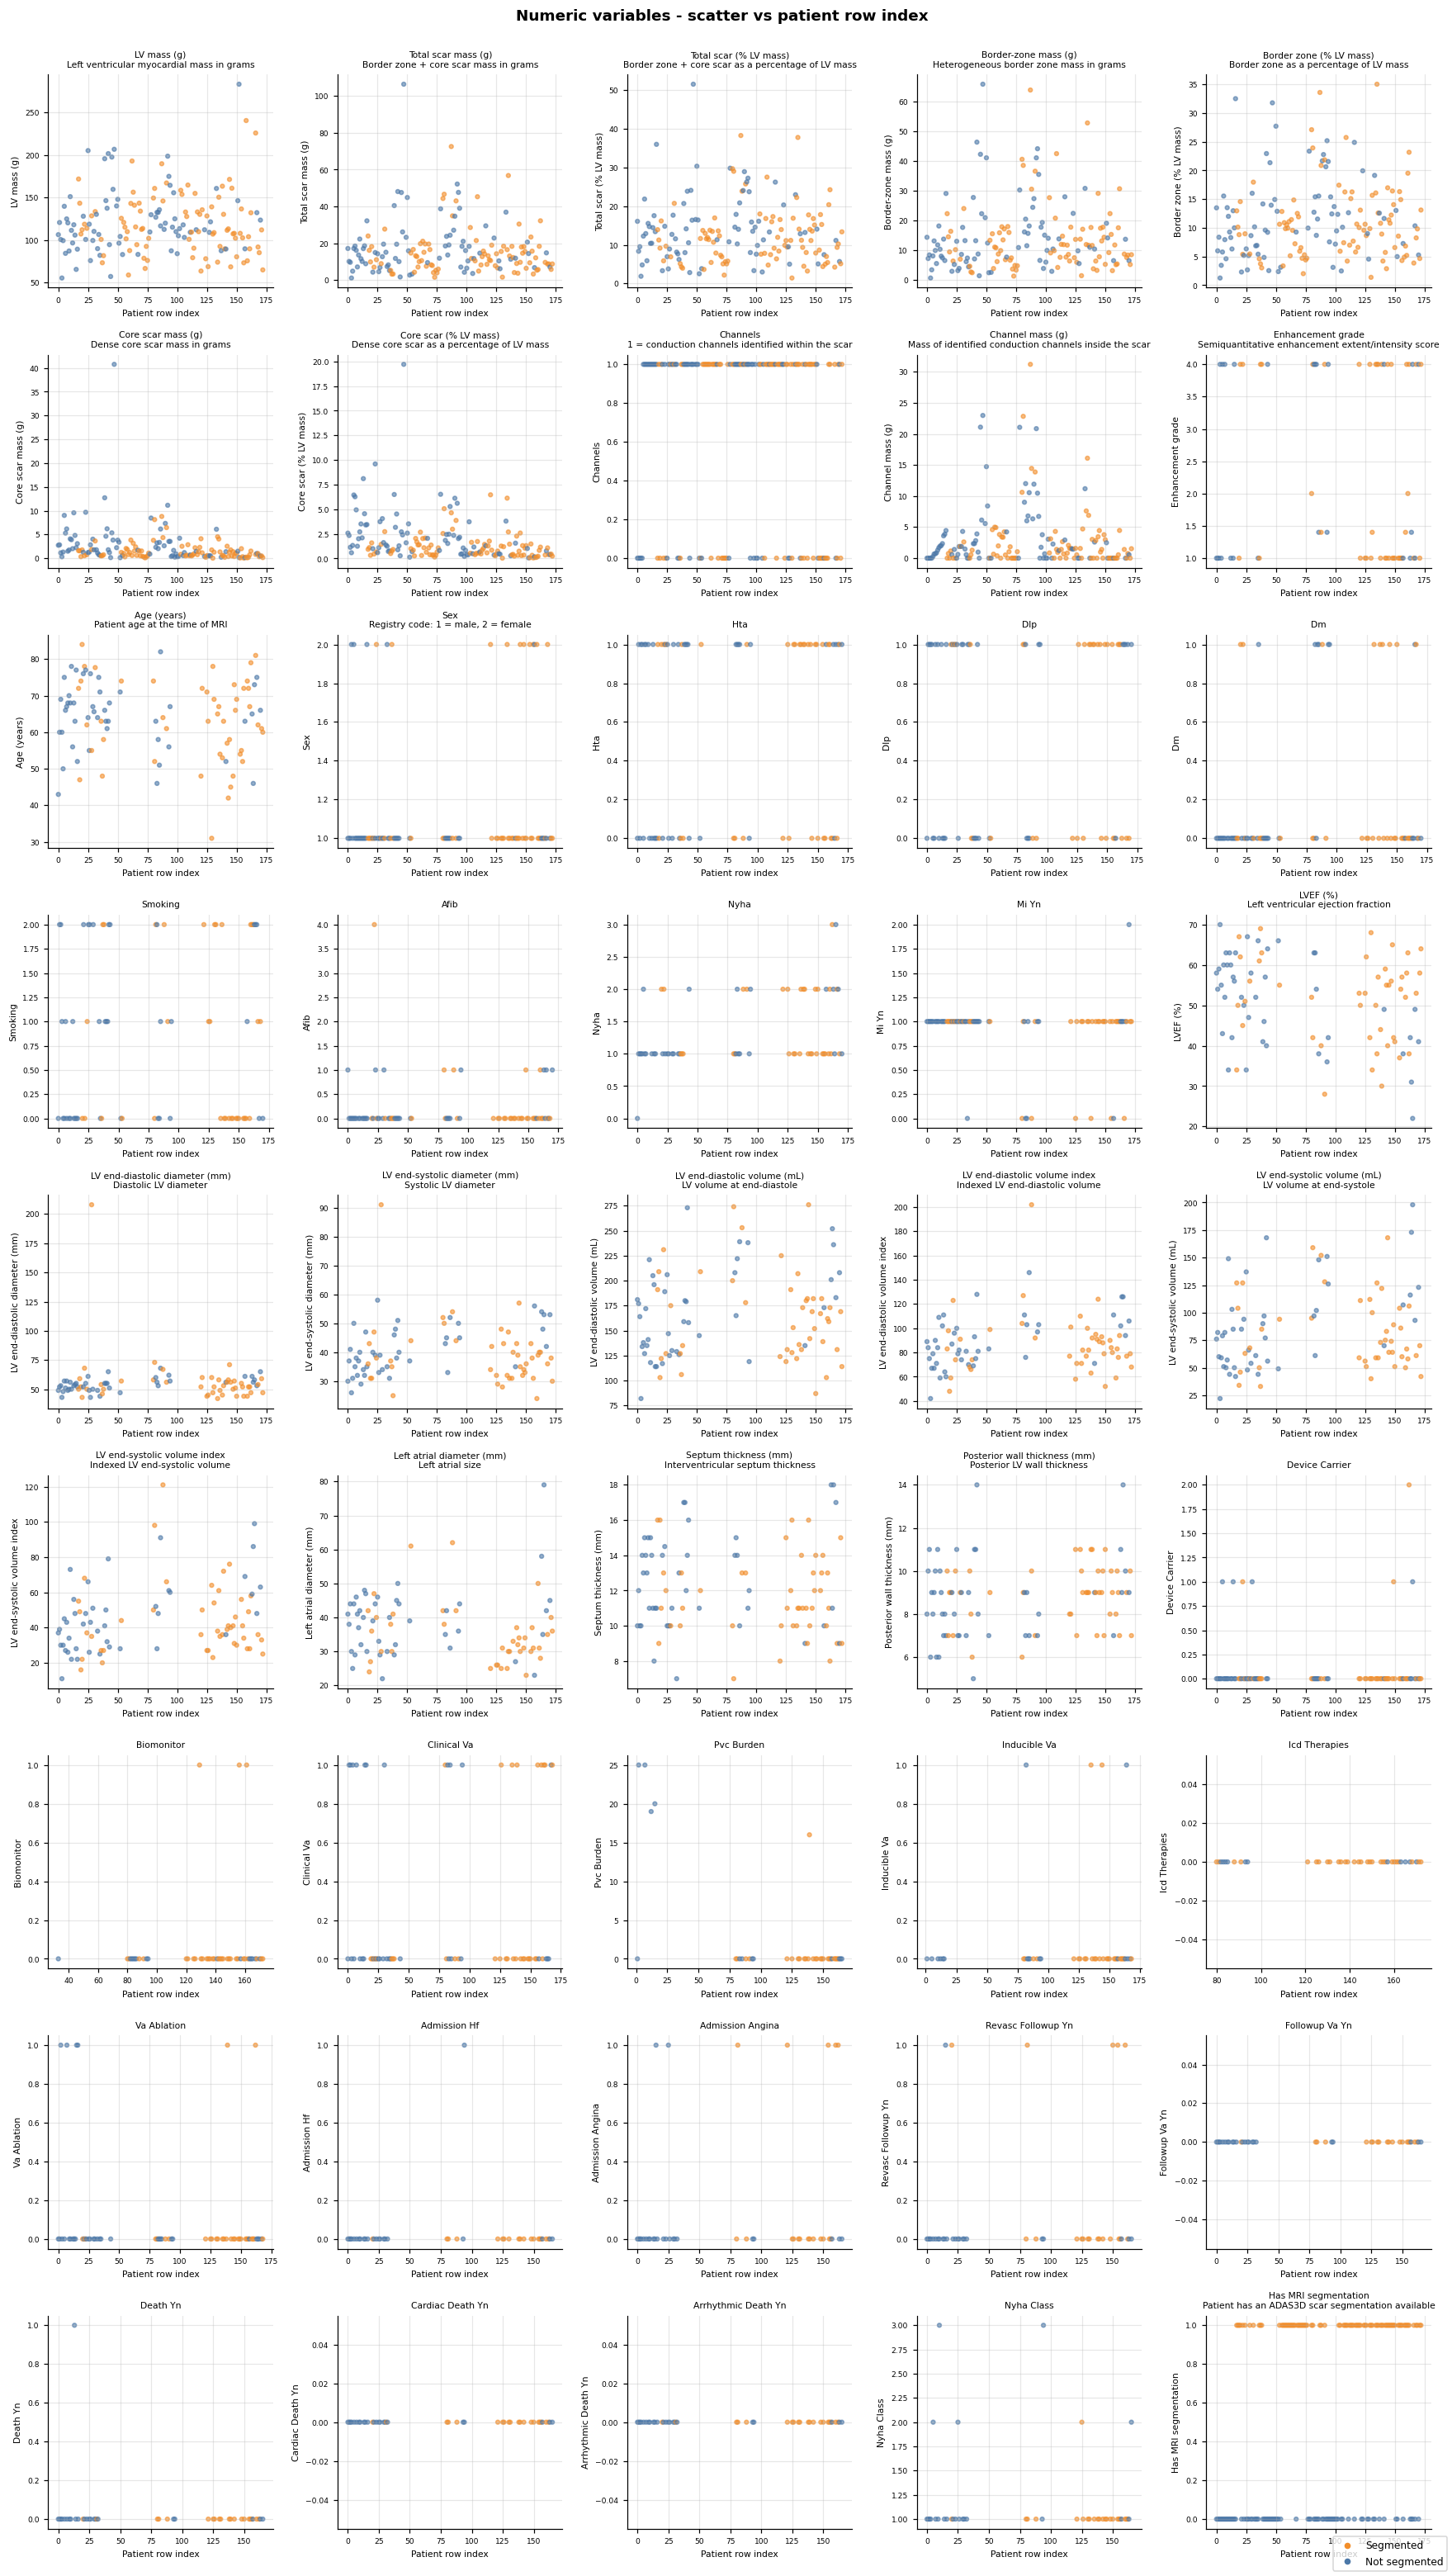

In [4]:
num_cols = [
    c for c in df.columns
    if pd.api.types.is_numeric_dtype(df[c])
    and df[c].notna().sum() >= 5
    and c not in ('patient_id', 'patient_id_norm')
]
color_map = df['has_segmentation'].map({True: SEG_COLOR, False: NO_SEG_COLOR})

n_cols = 5
n_rows = ceil(len(num_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.2 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    s = pd.to_numeric(df[col], errors='coerce')
    mask = s.notna()
    axes[i].scatter(s.index[mask], s.values[mask],
                    c=color_map[mask], alpha=0.6, s=10)
    axes[i].set_title(variable_title(col), fontsize=7)
    axes[i].set_xlabel('Patient row index', fontsize=7)
    axes[i].set_ylabel(variable_label(col), fontsize=7)
    axes[i].tick_params(labelsize=6)

for ax in axes[len(num_cols):]:
    ax.set_visible(False)

from matplotlib.lines import Line2D
fig.legend(
    handles=[
        Line2D([0], [0], marker='o', color='w', markerfacecolor=SEG_COLOR, markersize=6, label='Segmented'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=NO_SEG_COLOR, markersize=6, label='Not segmented'),
    ],
    loc='lower right', fontsize=8,
)
plt.suptitle('Numeric variables - scatter vs patient row index', fontweight='bold')
plt.tight_layout(rect=(0, 0, 1, 0.98))
plt.savefig(RESULTS_DIR / '01a_num_scatter.png', bbox_inches='tight')
plt.show()



### 1c ? Categorical / binary columns ? value counts including unknown

Bars show the most frequent recorded categories. Missing / empty values are grouped as **Unknown** so they are visible instead of disappearing from the plot.



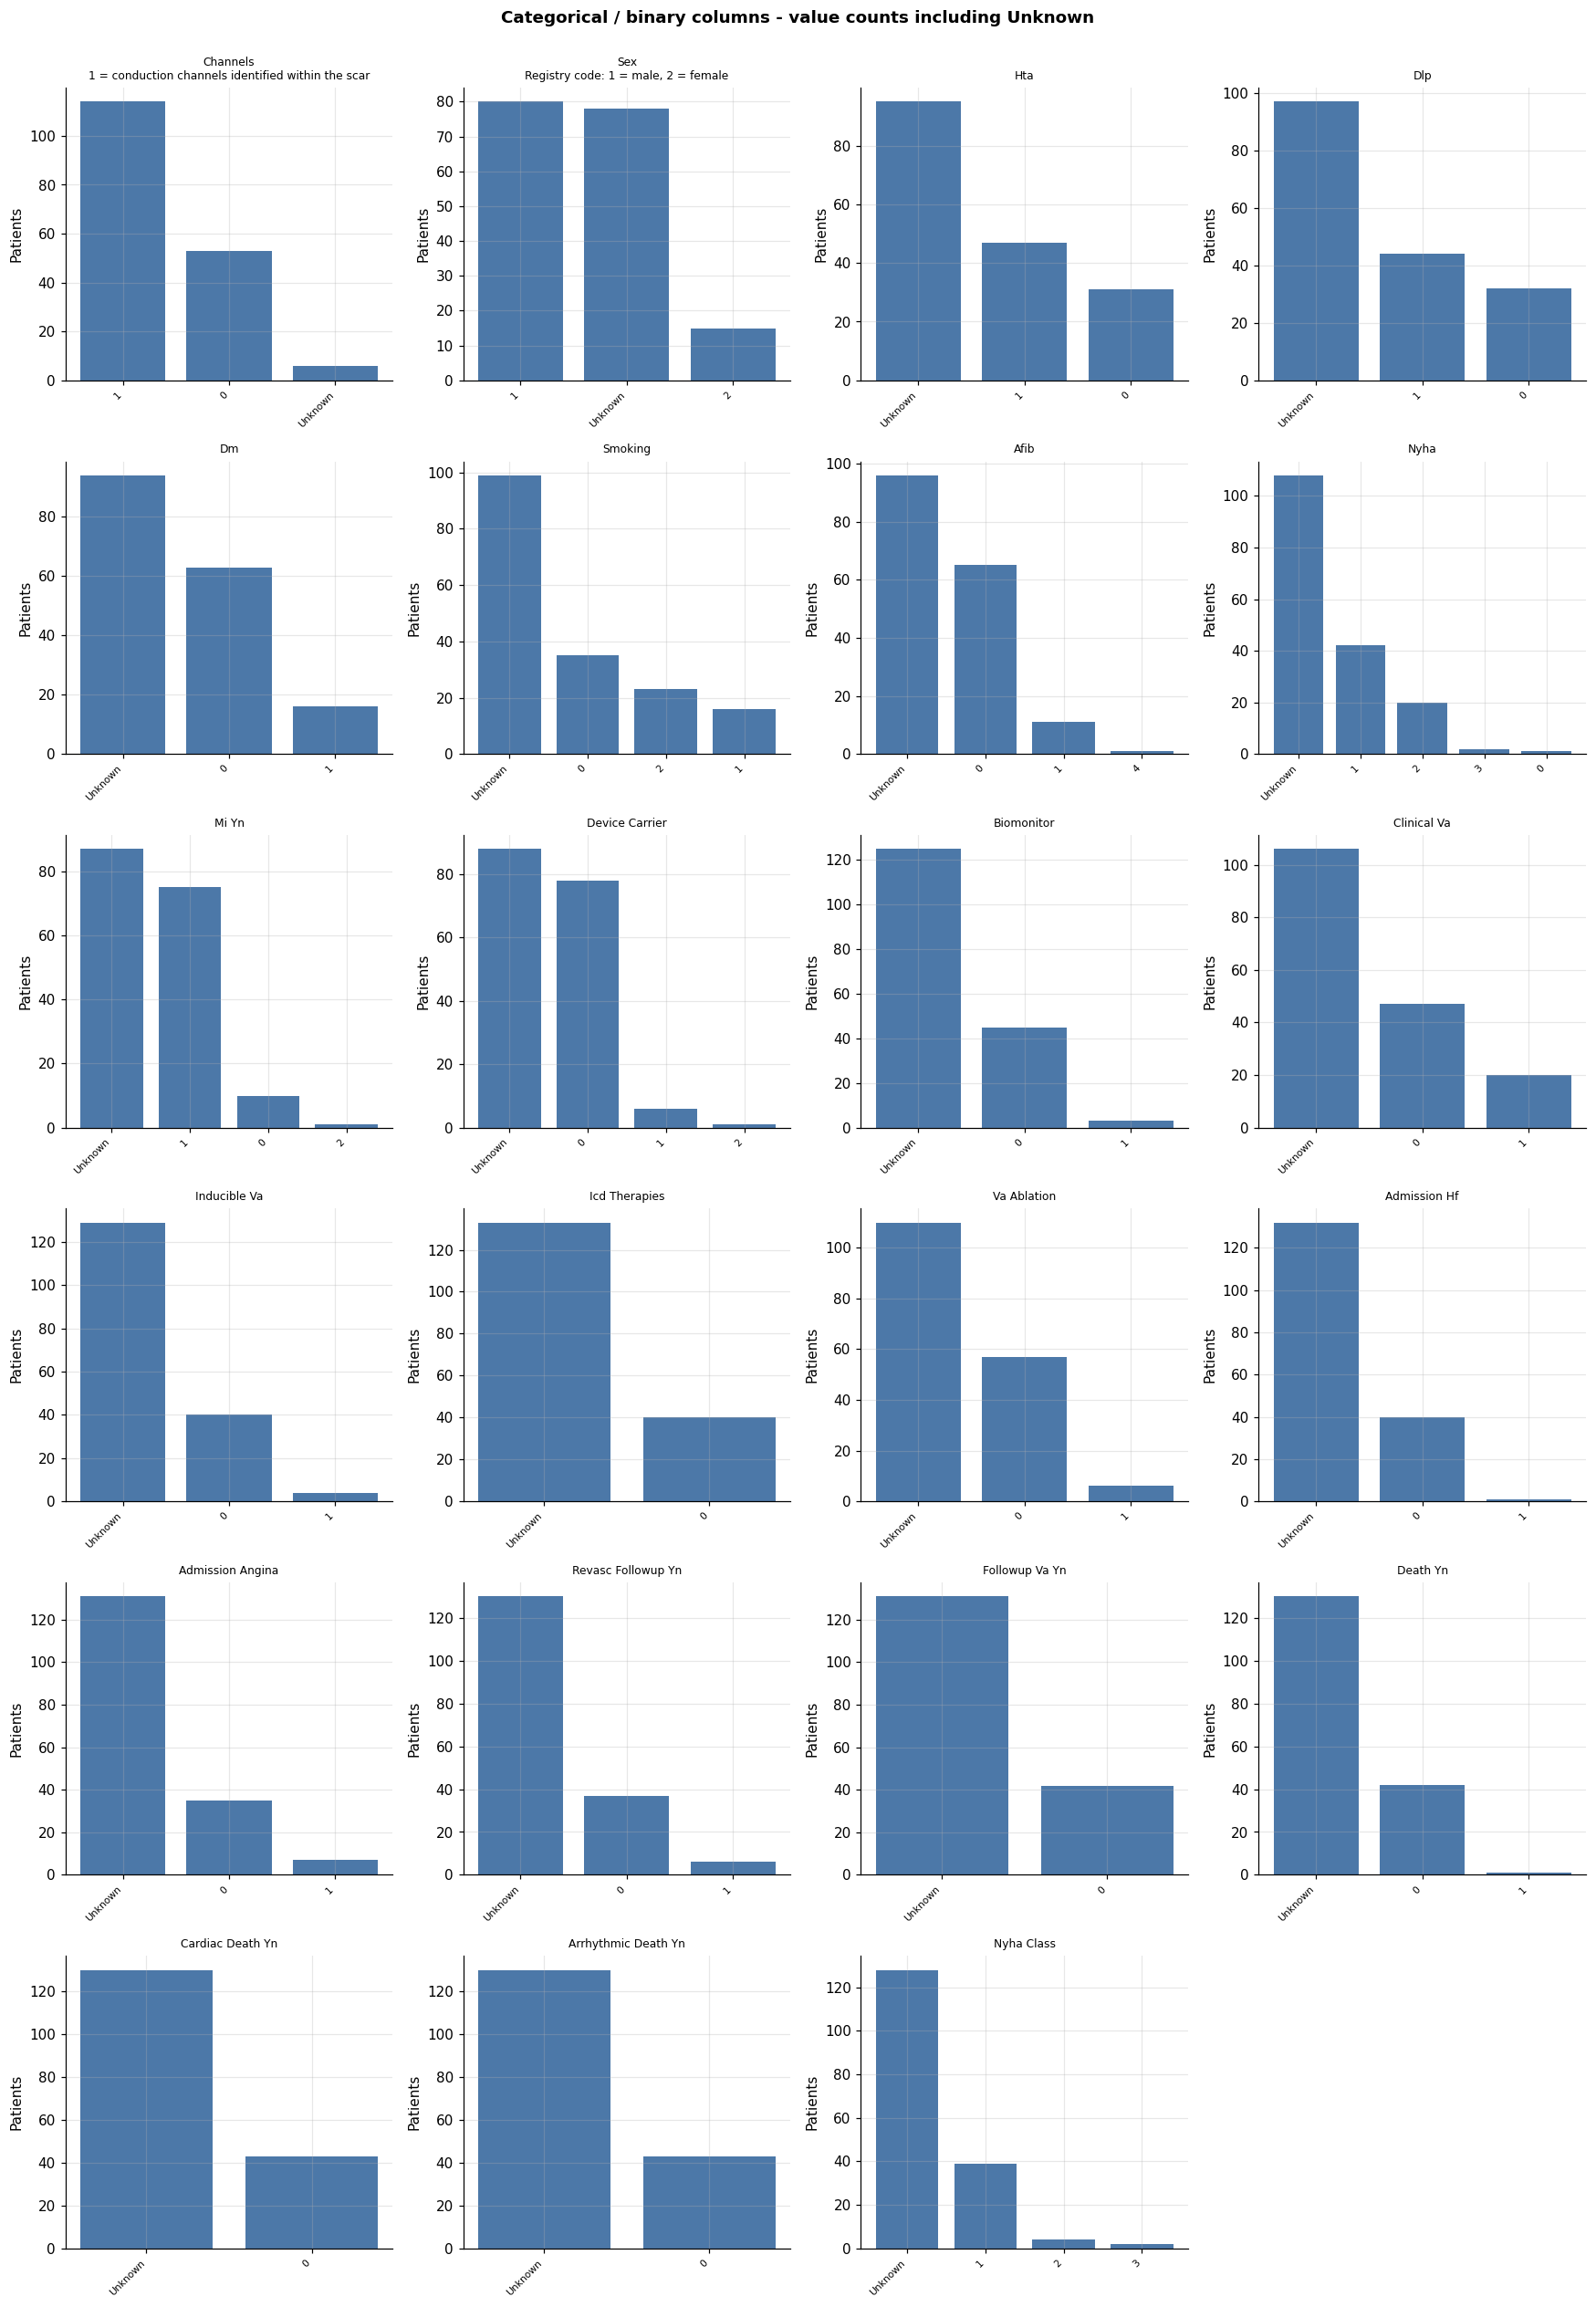

In [5]:
ignore = {
    c for c in df.columns
    if 'date' in c or c in ('patient_id', 'patient_id_norm', 'diagnosis', 'revasc_notes',
                             'other_notes', 'ablation_notes', 'va_notes',
                             'notes_misc', 'notes_followup_va')
}
cat_cols = [
    c for c in df.columns
    if c not in ignore
    and df[c].notna().sum() >= 3
    and (
        df[c].dtype == object
        or (pd.api.types.is_integer_dtype(df[c]) and df[c].nunique() <= 10)
    )
]

n_cols = 4
n_rows = ceil(len(cat_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.9 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    s = df[col].copy()
    if pd.api.types.is_object_dtype(s) or pd.api.types.is_string_dtype(s):
        s = s.replace('', np.nan)
    vc = s.astype('string').fillna('Unknown').value_counts(dropna=False).head(10)
    axes[i].bar(range(len(vc)), vc.values, color=HIST_COLOR)
    axes[i].set_xticks(range(len(vc)))
    axes[i].set_xticklabels(vc.index, rotation=45, ha='right', fontsize=7)
    axes[i].set_title(variable_title(col), fontsize=8)
    axes[i].set_ylabel('Patients')

for ax in axes[len(cat_cols):]:
    ax.set_visible(False)

plt.suptitle('Categorical / binary columns - value counts including Unknown', fontweight='bold')
plt.tight_layout(rect=(0, 0, 1, 0.98))
plt.savefig(RESULTS_DIR / '01b_cat_counts.png', bbox_inches='tight')
plt.show()



## 2 · Population characterization

One sub-section per variable group.
- Continuous variables with many unique values → **KDE density curve** with median marker
- Binary / low-cardinality / text variables → **horizontal bar chart** of value counts

Date columns are skipped (already visible in overview).

In [6]:
def plot_group(df, cols, title, save_name, n_cols=4, normalize_cols=None):
    normalize_cols = set(normalize_cols or [])
    skip = {c for c in cols if 'date' in c}
    pcols = [c for c in cols if c in df.columns and c not in skip]
    if not pcols:
        print(f'No plottable columns for: {title}')
        return

    n_rows = ceil(len(pcols) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.6 * n_cols, 4.0 * n_rows))
    axes = np.atleast_1d(axes).flatten()

    for i, col in enumerate(pcols):
        ax = axes[i]
        raw = df[col]
        s = raw.dropna()
        is_num = pd.api.types.is_numeric_dtype(raw)
        low_card = raw.nunique(dropna=True) <= 8

        if is_num and not low_card:
            vals = pd.to_numeric(s, errors='coerce').dropna()
            xlabel = variable_label(col)
            if col in normalize_cols and len(vals) >= 3 and float(vals.std()) > 0:
                vals = zscore(vals).dropna()
                xlabel = f'{variable_label(col)} (z-score)'
            if len(vals) >= 5 and float(vals.std()) > 0:
                xs = np.linspace(float(vals.min()), float(vals.max()), 200)
                kde = stats.gaussian_kde(vals)(xs)
                ax.fill_between(xs, kde, alpha=0.35, color=HIST_COLOR)
                ax.plot(xs, kde, color=HIST_COLOR, linewidth=1.8)
                ax.set_ylabel('Density', fontsize=8)
            else:
                ax.hist(vals, bins=12, color=HIST_COLOR, edgecolor='white')
                ax.set_ylabel('Patients', fontsize=8)
            if len(vals) > 0:
                ax.axvline(float(vals.median()), color='orange', linestyle=':',
                           linewidth=1.2, label=f'median {float(vals.median()):.1f}')
                ax.legend(fontsize=7, loc='upper right')
            ax.set_xlabel(xlabel, fontsize=8)
        else:
            text_s = s.copy()
            if pd.api.types.is_object_dtype(text_s) or pd.api.types.is_string_dtype(text_s):
                text_s = text_s.replace('', np.nan)
            vc = text_s.astype('string').fillna('Unknown').value_counts().head(8).sort_values()
            ax.barh(vc.index, vc.values, color=HIST_COLOR)
            ax.set_xlabel('Patients', fontsize=8)
            ax.tick_params(axis='y', labelsize=7)

        ax.set_title(variable_title(col), fontsize=9)
        ax.tick_params(axis='x', labelsize=7)

    for ax in axes[len(pcols):]:
        ax.set_visible(False)

    plt.suptitle(title, fontweight='bold', fontsize=12)
    plt.tight_layout(rect=(0, 0, 1, 0.97), h_pad=2.0, w_pad=1.4)
    plt.savefig(RESULTS_DIR / f'{save_name}.png', bbox_inches='tight')
    plt.show()


### 2a · Demographics

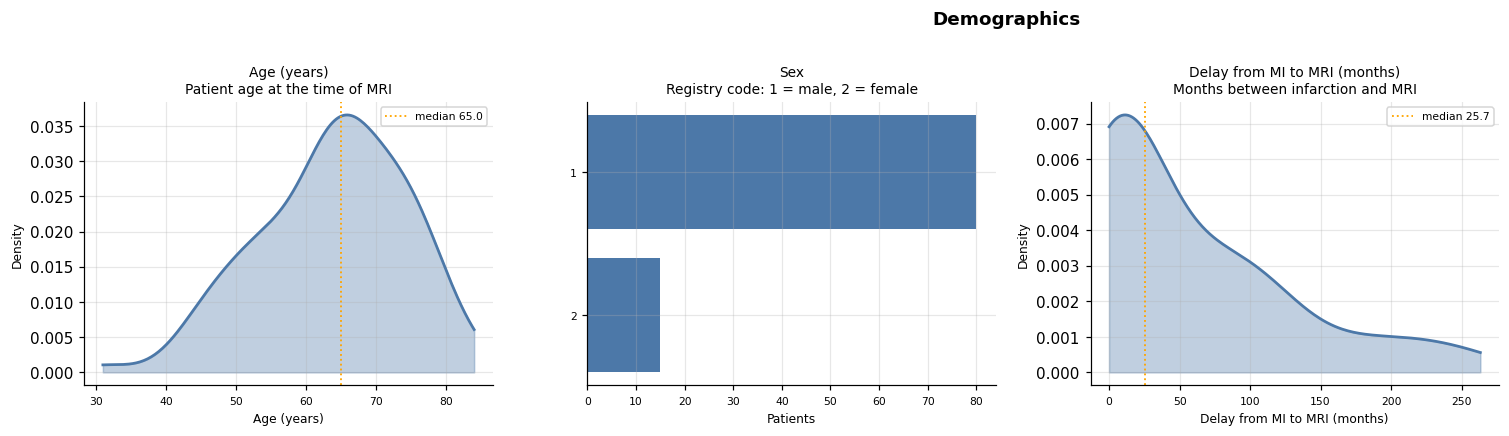

In [7]:
# Add MI-to-MRI delay in months as a derived column
if {'date_mi', 'date_mri'}.issubset(df.columns):
    df['mi_to_mri_months'] = (df['date_mri'] - df['date_mi']).dt.days / 30.44

demo_extra = ['age', 'sex', 'mi_to_mri_months']
plot_group(df, demo_extra, 'Demographics', '02a_demographics')

### 2b · MRI scar variables

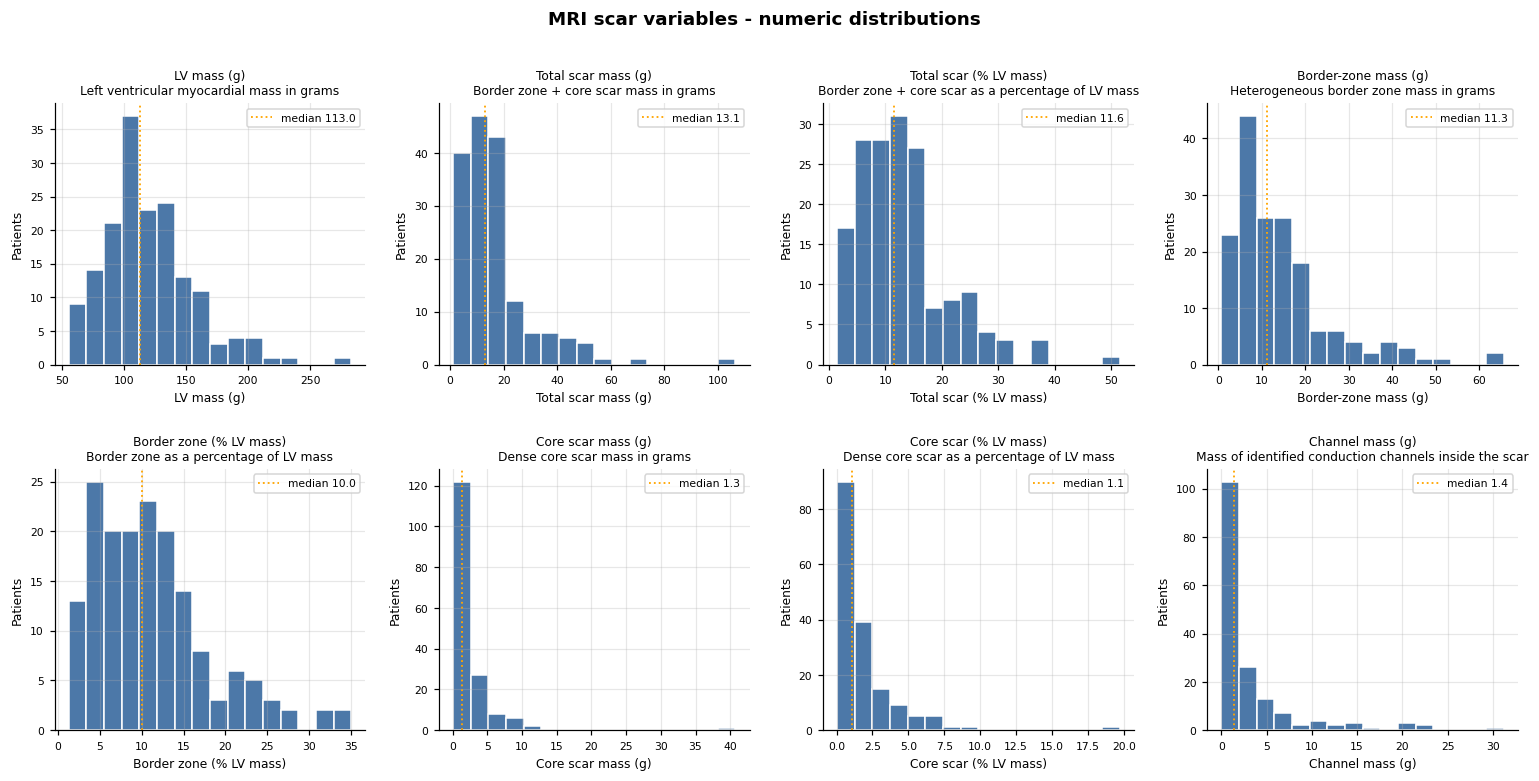

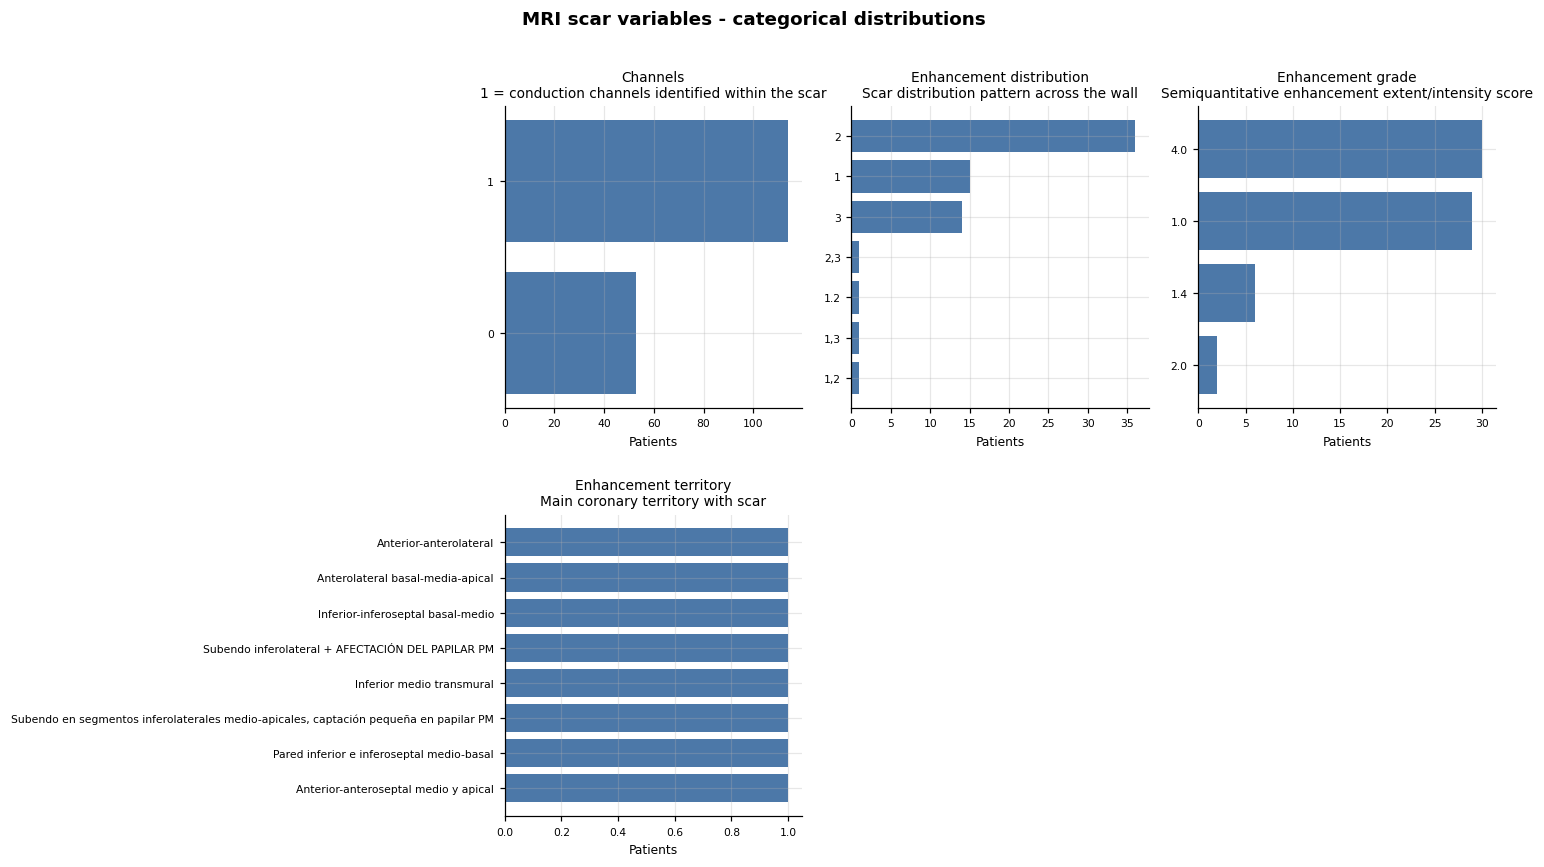

In [8]:
scar_cols = [c for c in COLUMN_GROUPS['scar_geometry'] if c in df.columns and 'date' not in c]
scar_num = [c for c in scar_cols if pd.api.types.is_numeric_dtype(df[c]) and df[c].nunique(dropna=True) > 8]
scar_cat = [c for c in scar_cols if c not in scar_num]

if scar_num:
    n_cols = 4
    n_rows = ceil(len(scar_num) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.6 * n_rows))
    axes = np.atleast_1d(axes).flatten()

    for i, col in enumerate(scar_num):
        vals = pd.to_numeric(df[col], errors='coerce').dropna()
        axes[i].hist(vals, bins=16, color=HIST_COLOR, edgecolor='white')
        axes[i].axvline(float(vals.median()), color='orange', linestyle=':',
                        linewidth=1.2, label=f'median {float(vals.median()):.1f}')
        axes[i].set_title(variable_title(col), fontsize=8)
        axes[i].set_xlabel(variable_label(col), fontsize=8)
        axes[i].set_ylabel('Patients', fontsize=8)
        axes[i].tick_params(axis='x', labelsize=7)
        axes[i].tick_params(axis='y', labelsize=7)
        axes[i].legend(fontsize=7)

    for ax in axes[len(scar_num):]:
        ax.set_visible(False)

    plt.suptitle('MRI scar variables - numeric distributions', fontweight='bold')
    plt.tight_layout(rect=(0, 0, 1, 0.97), h_pad=2.0, w_pad=1.5)
    plt.savefig(RESULTS_DIR / '02b_scar_numeric.png', bbox_inches='tight')
    plt.show()

if scar_cat:
    plot_group(df, scar_cat, 'MRI scar variables - categorical distributions', '02b_scar_categorical', n_cols=3)


### 2c · Risk factors

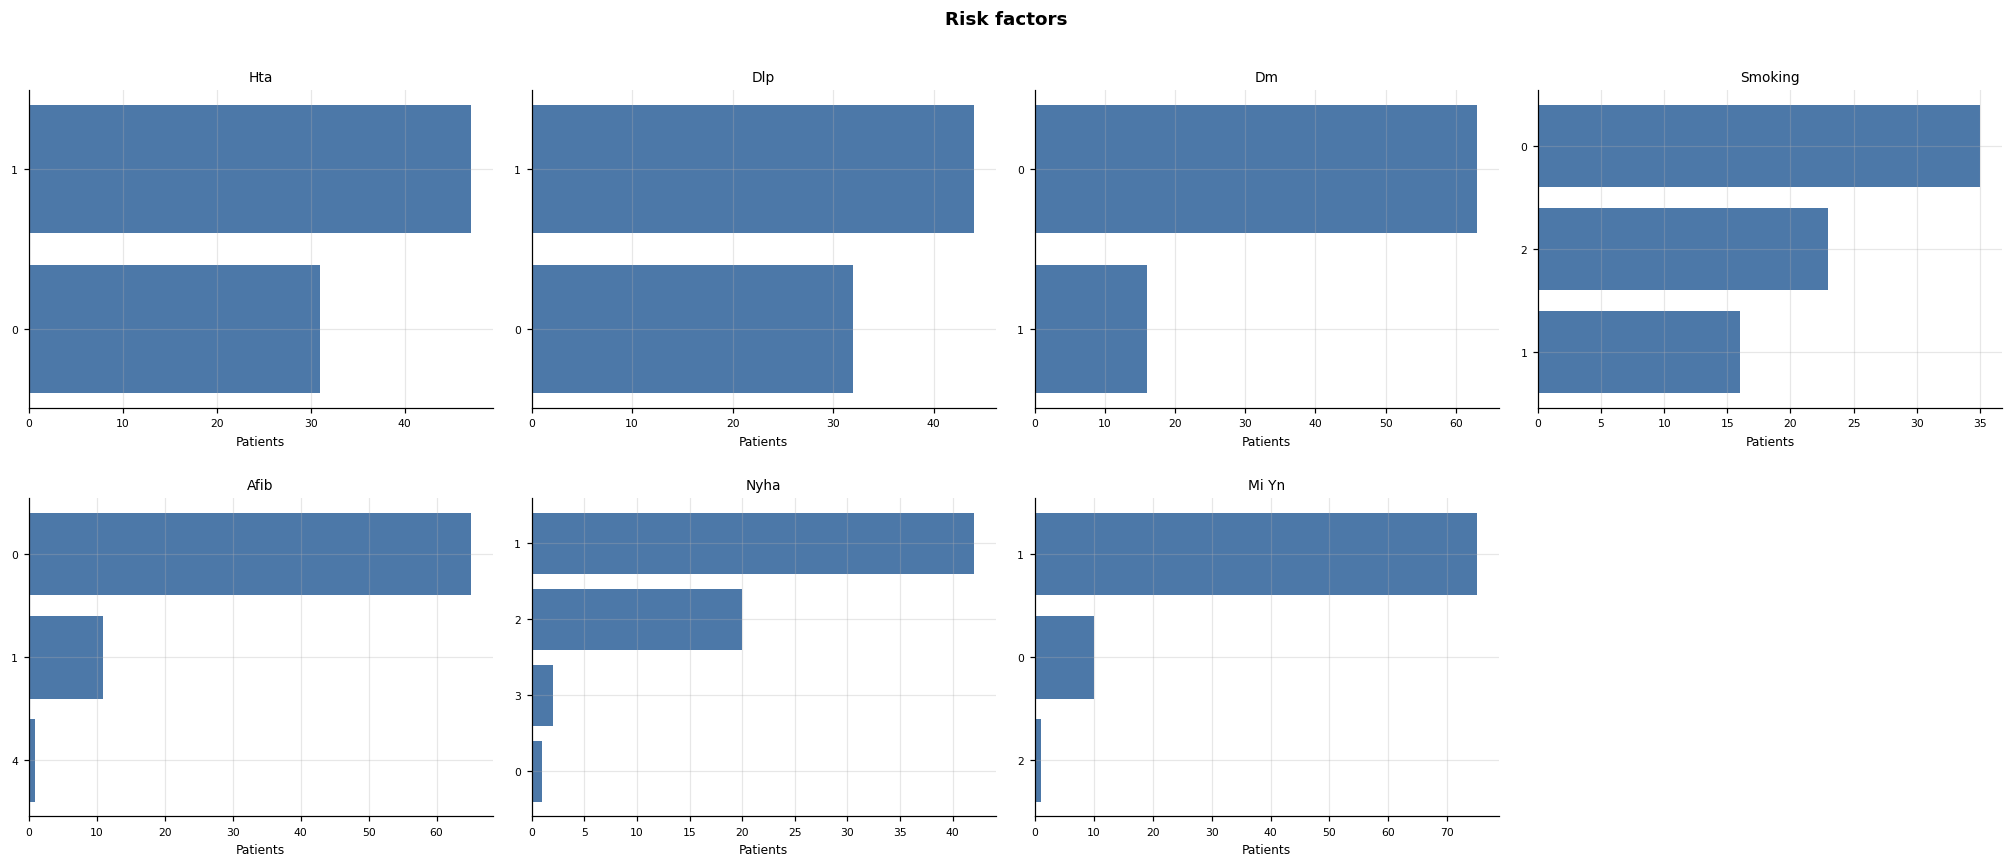

In [9]:
plot_group(df, COLUMN_GROUPS['risk_factors'], 'Risk factors', '02c_risk_factors')

### 2d · Infarctions & revascularization

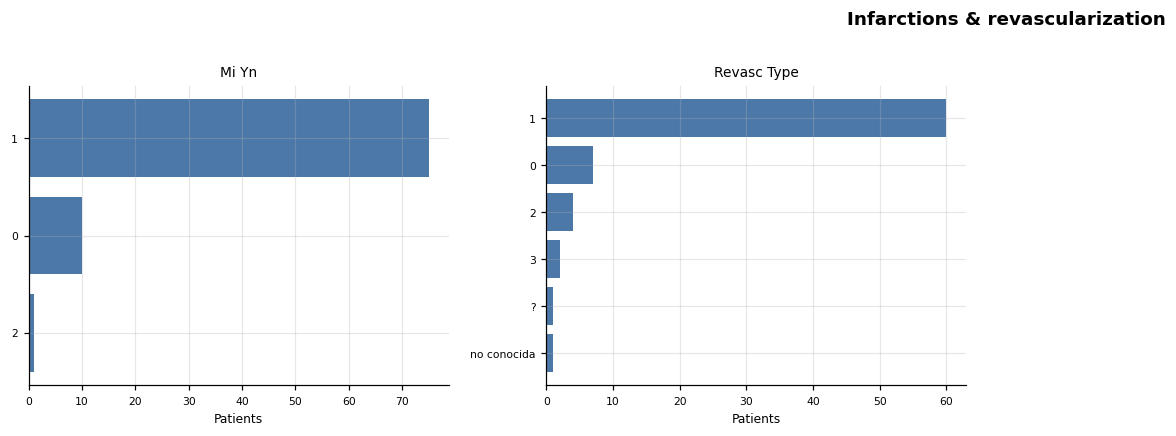

In [10]:
infarct_cols = [c for c in ['mi_yn', 'revasc_type', 'date_revasc'] if c in df.columns]
plot_group(df, infarct_cols, 'Infarctions & revascularization', '02d_infarct')

### 2e · Cardiac structure and function

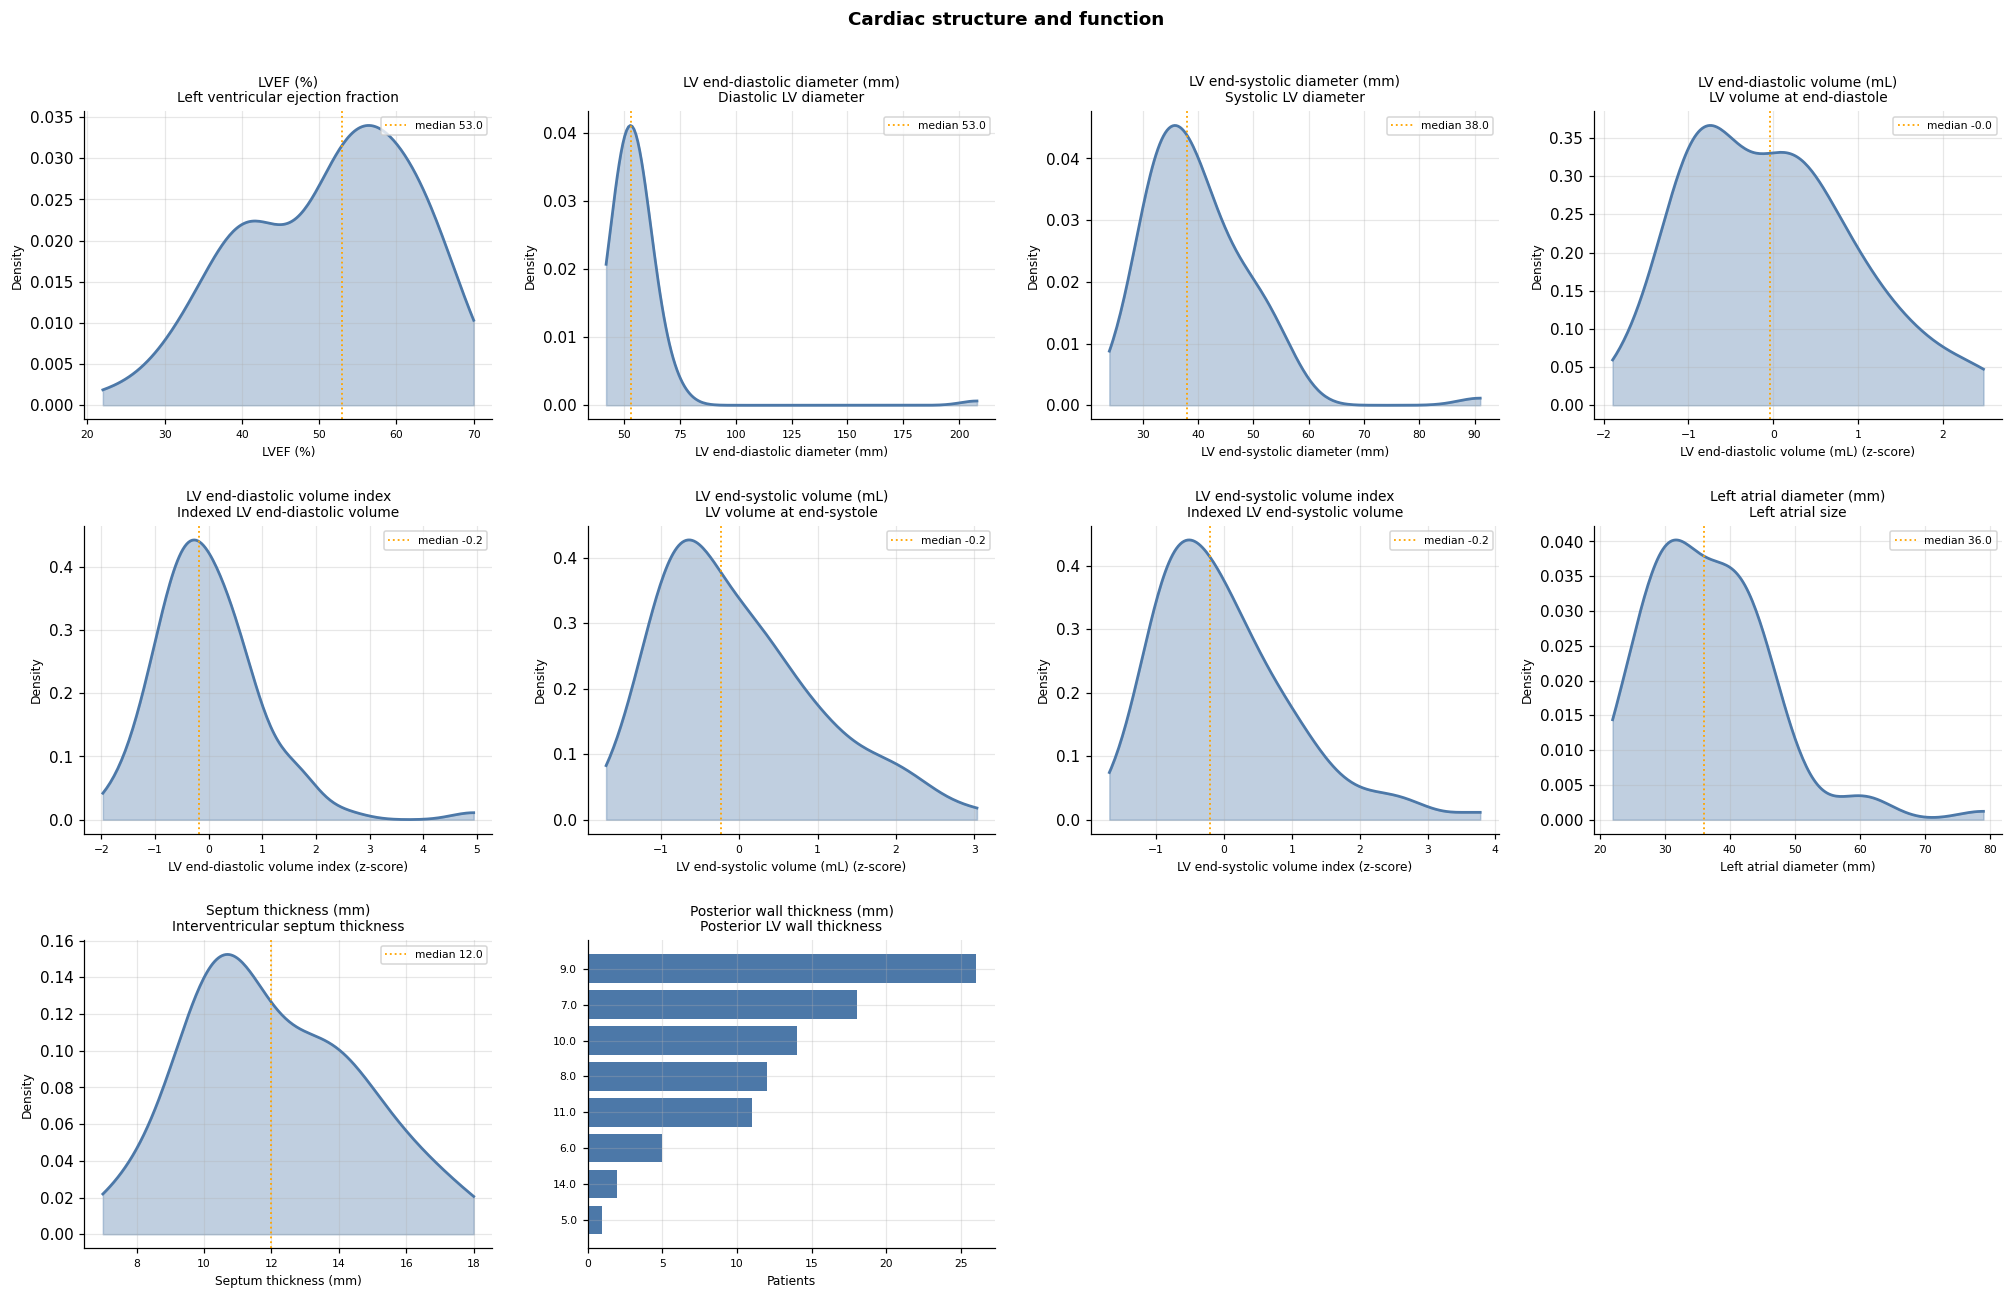

In [11]:
echo_normalized = [c for c in ['lvedv_ml', 'lvedv_index', 'lvesv_ml', 'lvesv_index'] if c in df.columns]
plot_group(df, COLUMN_GROUPS['echo'], 'Cardiac structure and function', '02e_echo', normalize_cols=echo_normalized)


### 2f · Devices

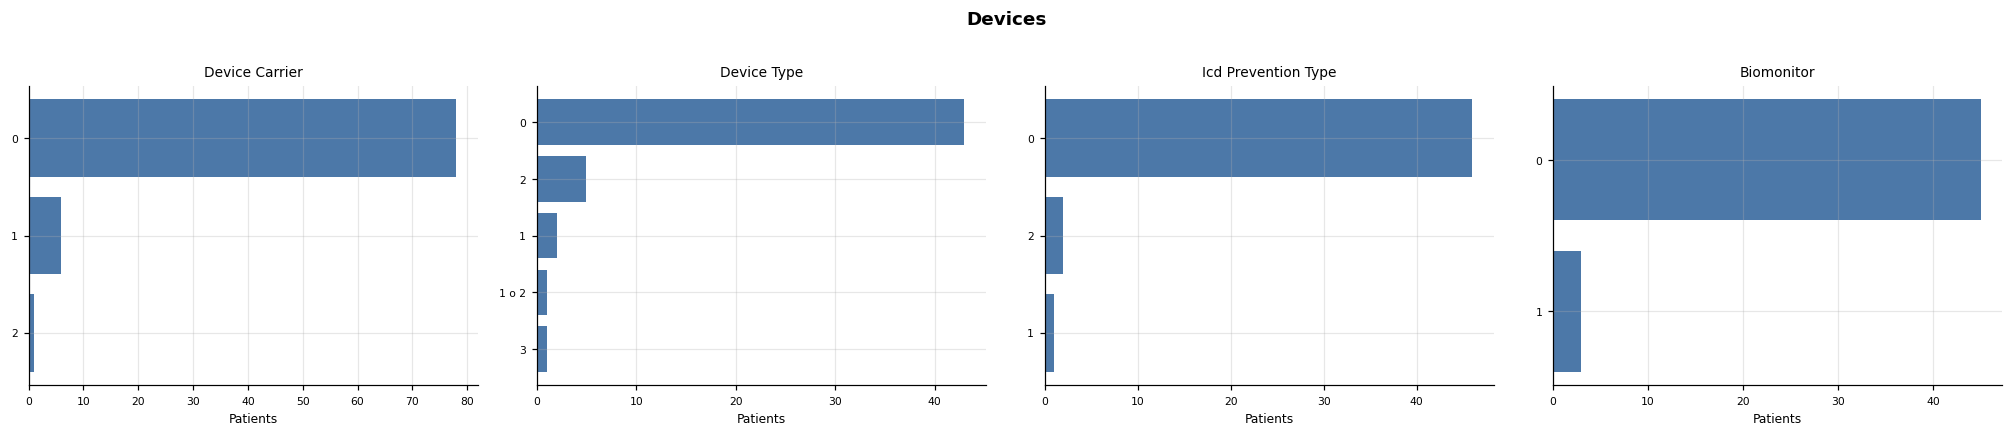

In [12]:
plot_group(df, COLUMN_GROUPS['devices'], 'Devices', '02f_devices')

### 2g · Ventricular arrhythmias

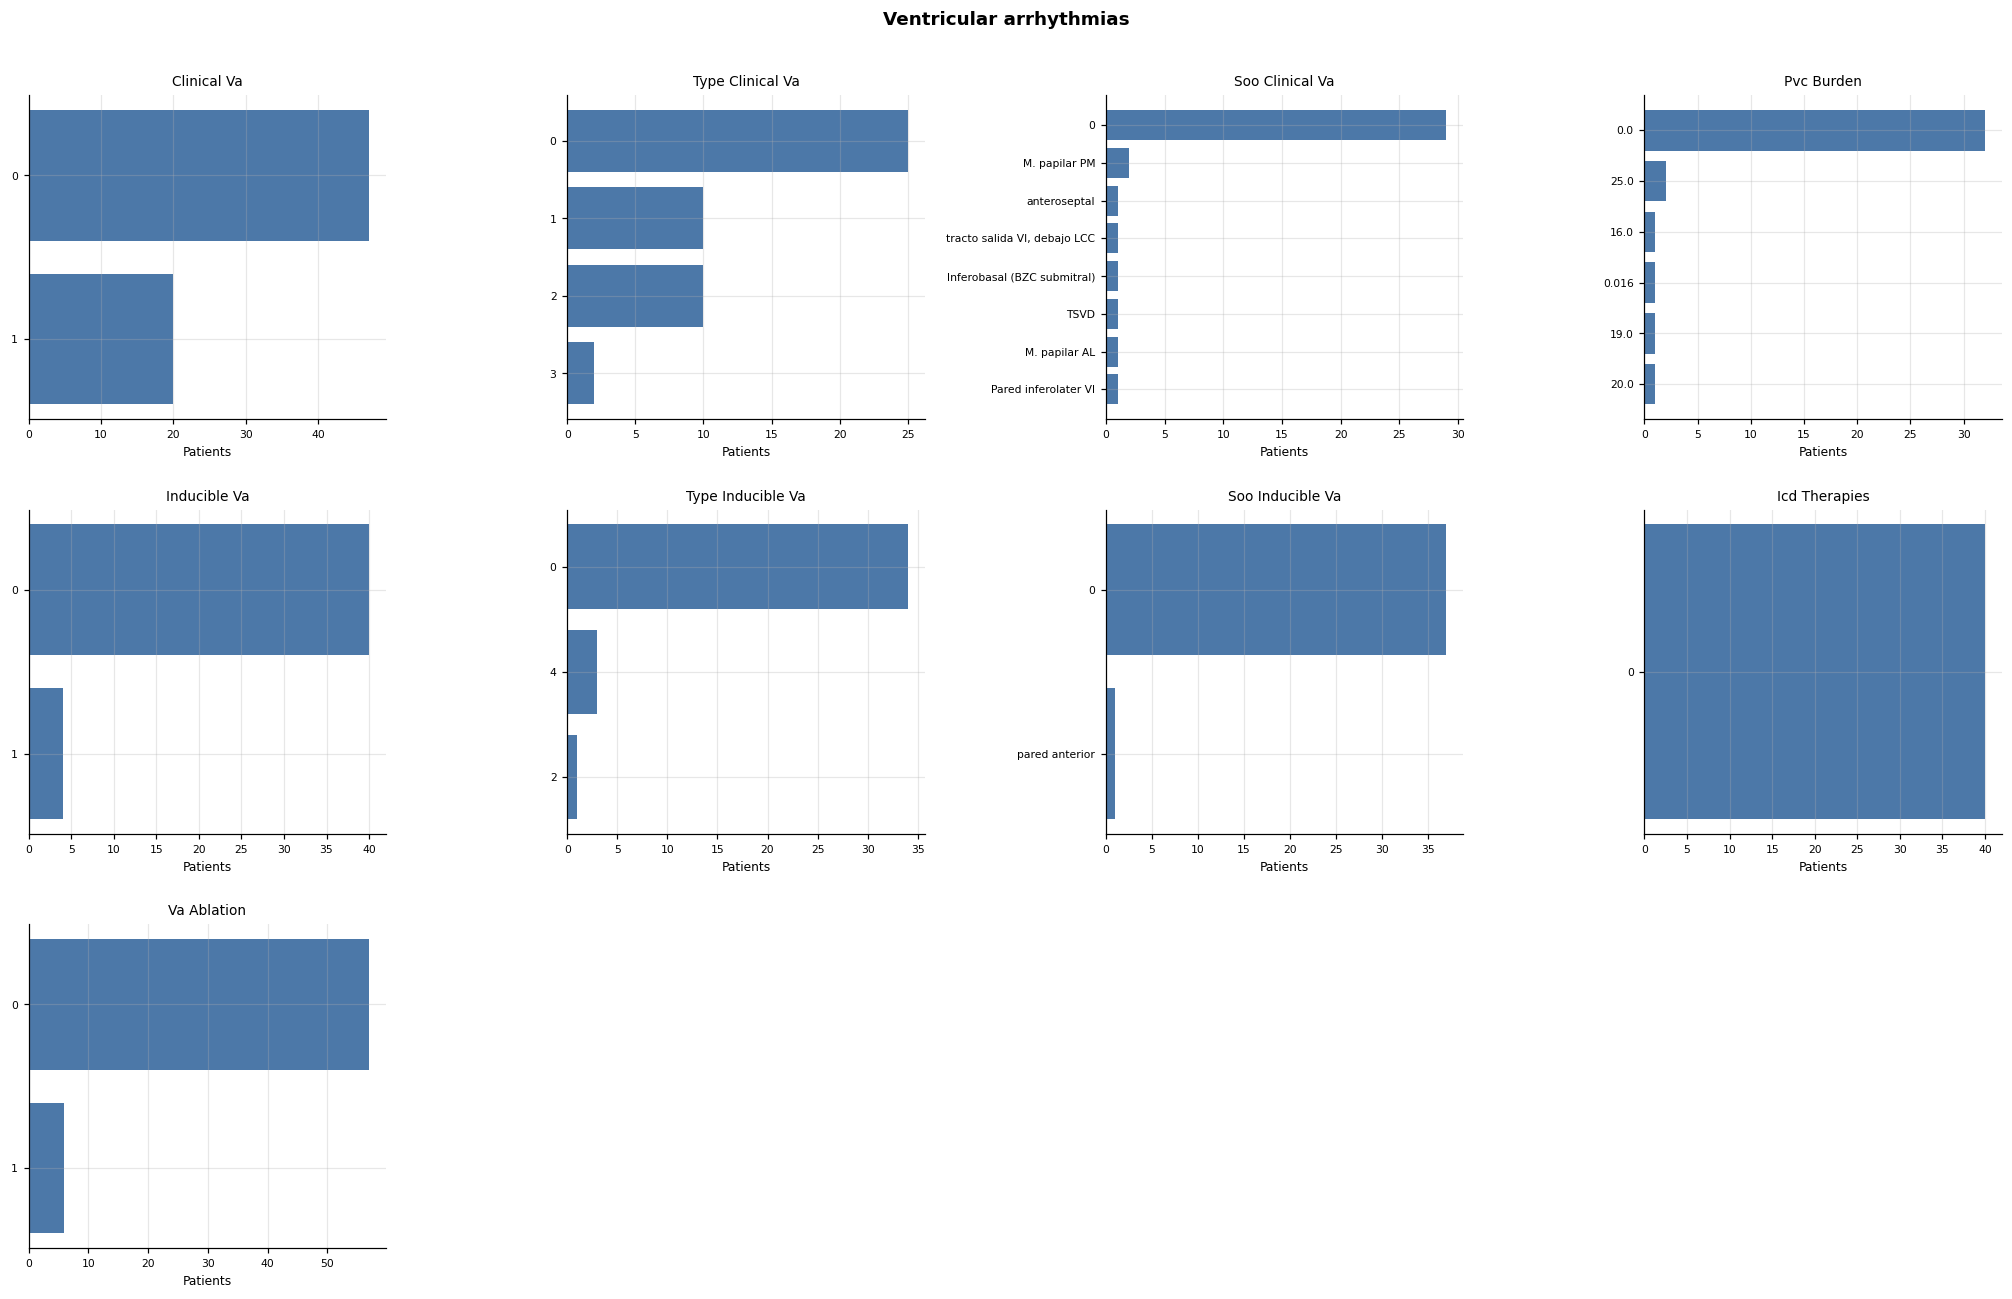

In [13]:
plot_group(df, COLUMN_GROUPS['arrhythmias'], 'Ventricular arrhythmias', '02g_arrhythmias')

### 2h · Medications

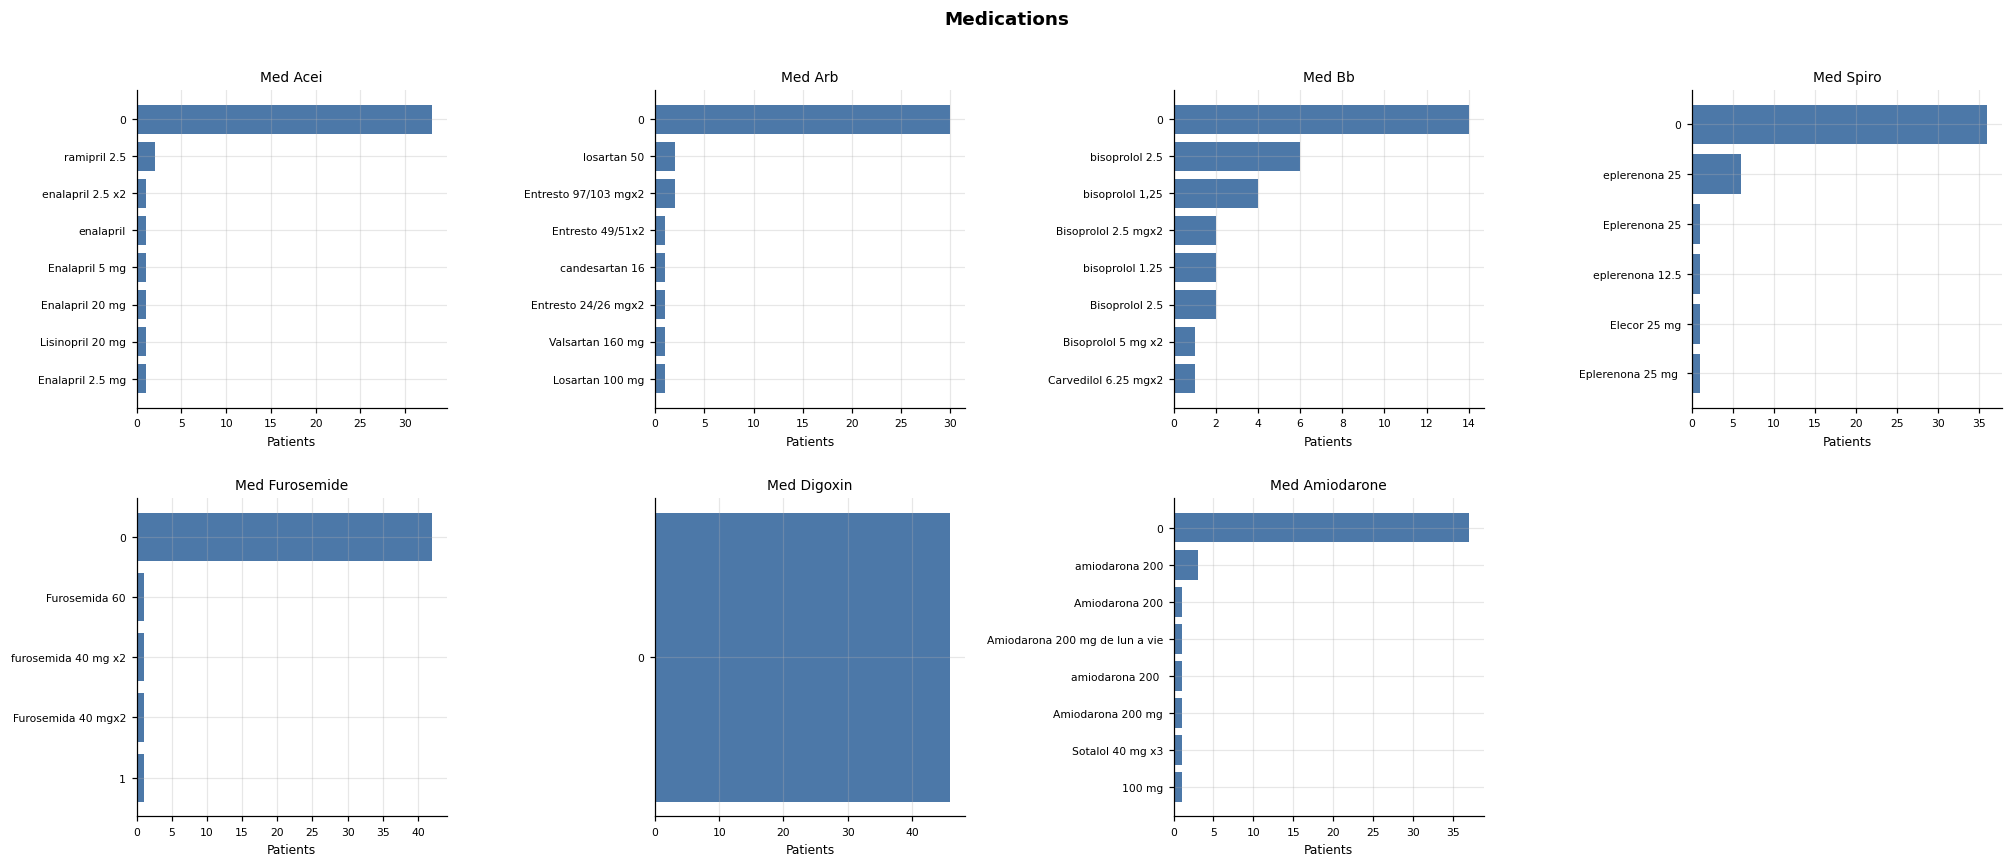

In [14]:
plot_group(df, COLUMN_GROUPS['medications'], 'Medications', '02h_medications')

### 2i · Follow-up outcomes

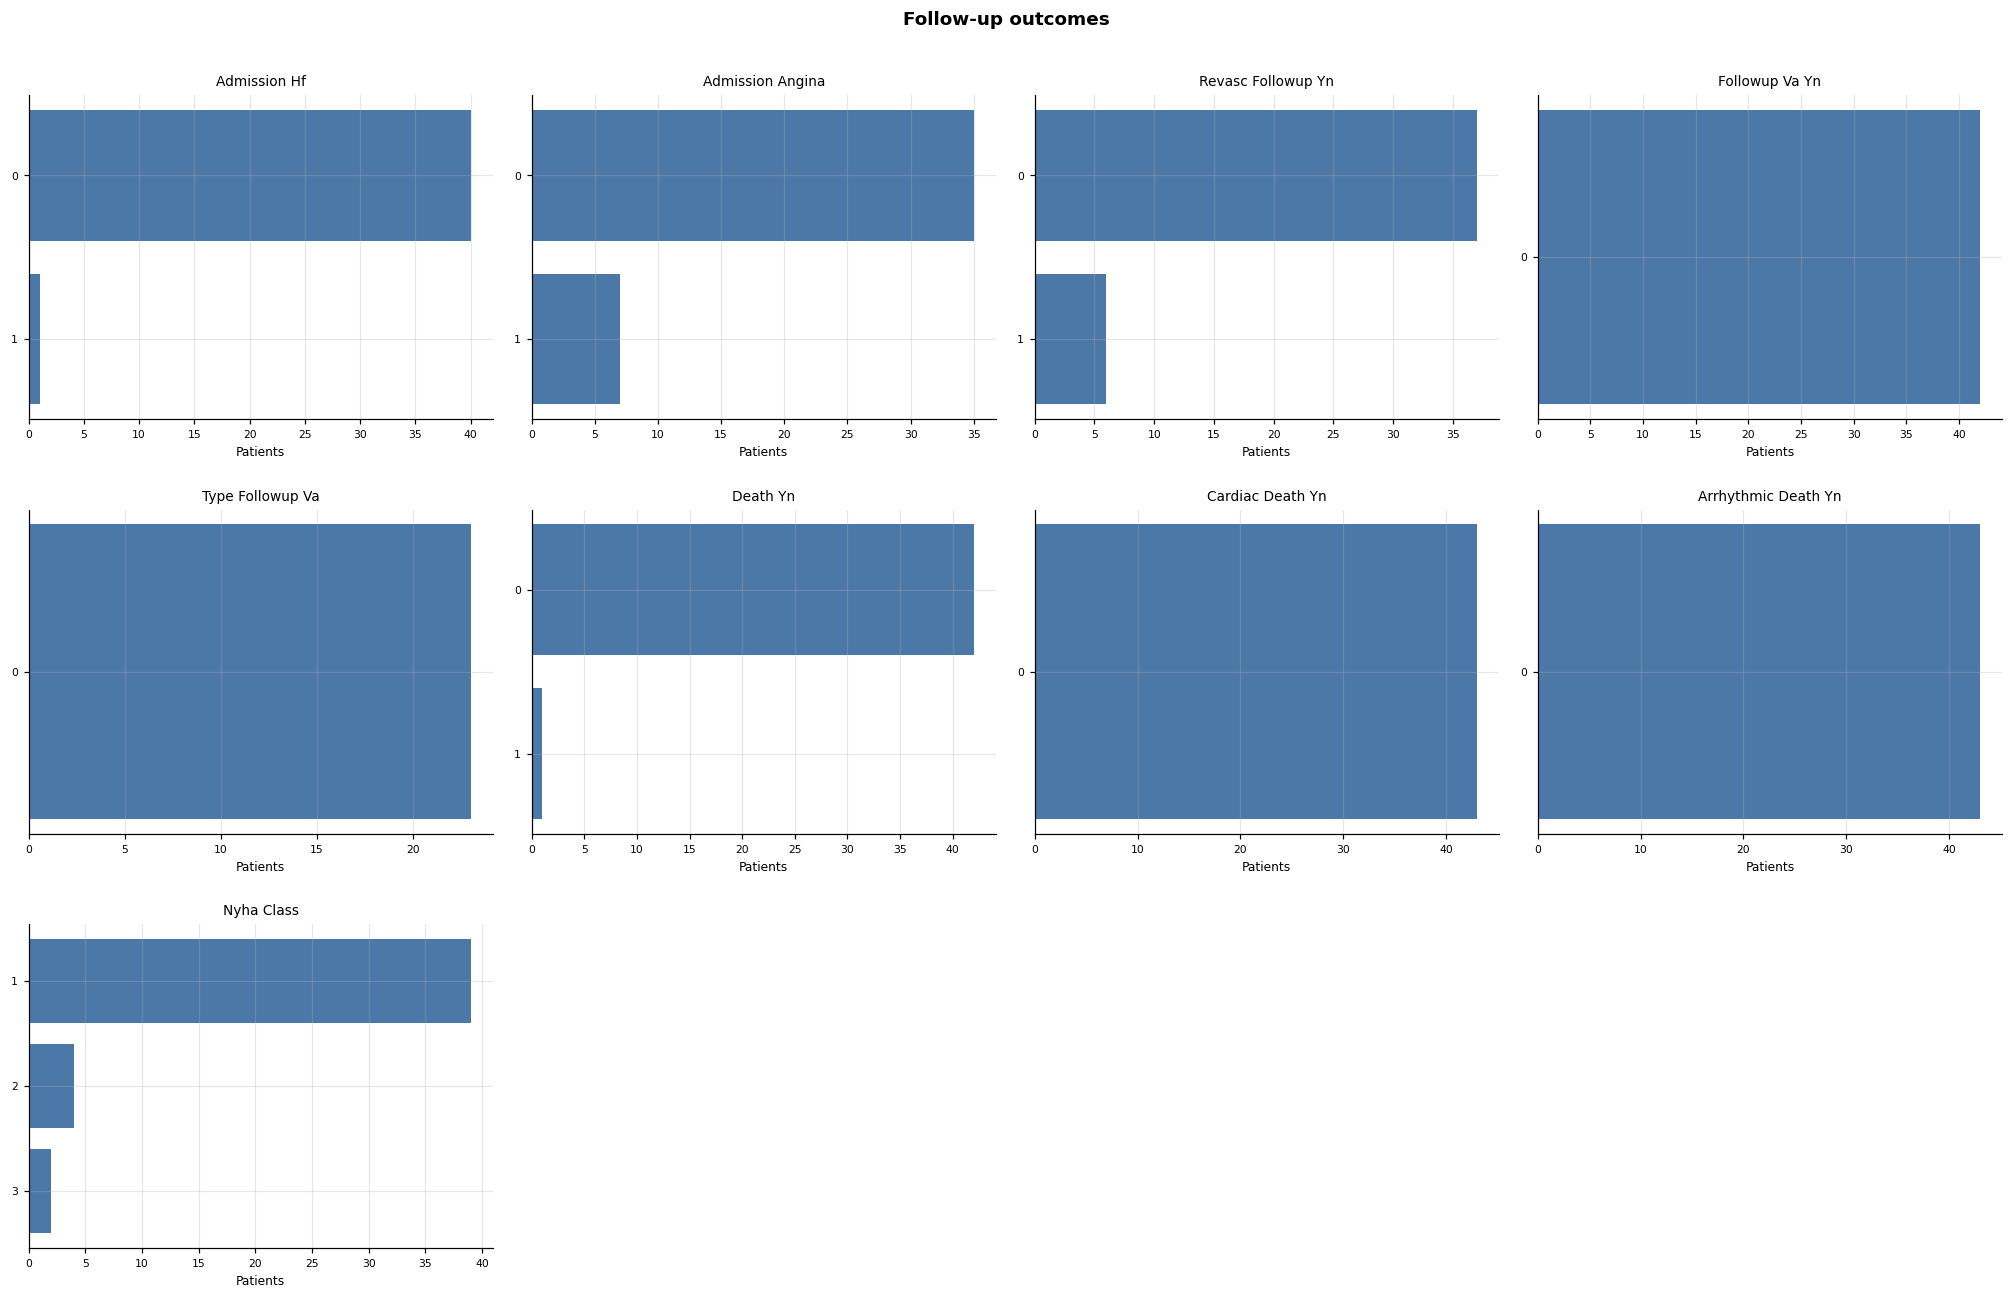

In [15]:
plot_group(df, COLUMN_GROUPS['followup'], 'Follow-up outcomes', '02i_followup')

## 3 · Risk factors

Stacked bar: **green** = factor present, **grey** = absent, **red hatched** = not recorded.
All bars add up to 100% of the total cohort.

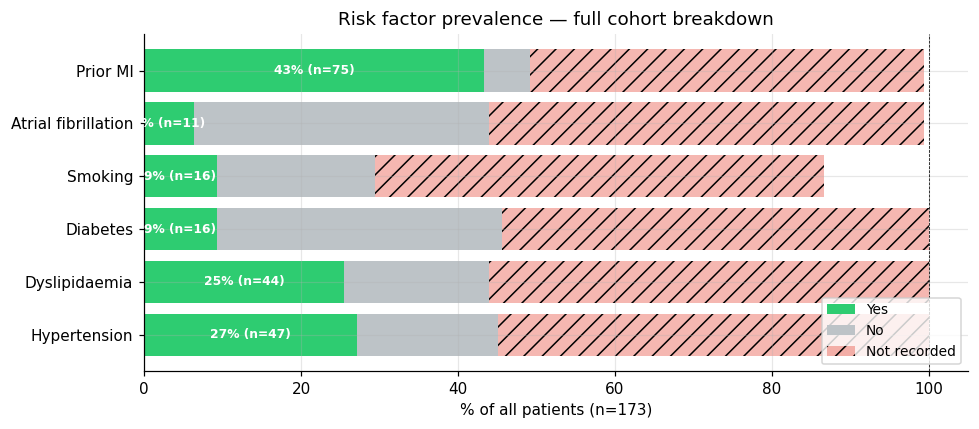

NYHA class distribution:
nyha
0         1
1        42
2        20
3         2
<NA>    108
Name: count, dtype: Int64


In [16]:
rf_cols   = [c for c in ['hta', 'dlp', 'dm', 'smoking', 'afib', 'mi_yn'] if c in df.columns]
rf_labels = {
    'hta': 'Hypertension', 'dlp': 'Dyslipidaemia', 'dm': 'Diabetes',
    'smoking': 'Smoking', 'afib': 'Atrial fibrillation', 'mi_yn': 'Prior MI',
}
n_total = len(df)

yes_pct  = [(df[c] == 1).sum() / n_total * 100 for c in rf_cols]
no_pct   = [(df[c] == 0).sum() / n_total * 100 for c in rf_cols]
miss_pct = [df[c].isna().sum()  / n_total * 100 for c in rf_cols]
labels   = [rf_labels.get(c, c) for c in rf_cols]

fig, ax = plt.subplots(figsize=(9, 4))
y = list(range(len(rf_cols)))
ax.barh(y, yes_pct, color='#2ecc71', label='Yes')
ax.barh(y, no_pct,  left=yes_pct,    color='#bdc3c7', label='No')
ax.barh(y, miss_pct,
        left=[a + b for a, b in zip(yes_pct, no_pct)],
        color='#e74c3c', alpha=0.4, hatch='//', label='Not recorded')

ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlabel('% of all patients (n=173)')
ax.set_xlim(0, 105)
ax.axvline(100, color='black', linewidth=0.5, linestyle='--')
ax.set_title('Risk factor prevalence — full cohort breakdown')
ax.legend(loc='lower right', fontsize=9)

for i, (pct, c) in enumerate(zip(yes_pct, rf_cols)):
    n = int((df[c] == 1).sum())
    if pct > 5:
        ax.text(pct / 2, i, f'{pct:.0f}% (n={n})',
                ha='center', va='center', fontsize=8,
                color='white', fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / '03_risk_factors.png', bbox_inches='tight')
plt.show()

if 'nyha' in df.columns:
    print('NYHA class distribution:')
    print(df['nyha'].value_counts(dropna=False).sort_index())

## 4 - Scar geometry (detailed)

### Variable glossary

`pct` means **percentage**. In this notebook, scar variables ending in `_pct` are percentages of LV mass, not raw grams.
For example, `bz_core_pct` = total scar burden normalized by LV mass, while `bz_core_g` = total scar burden in grams.

| Variable | Meaning |
|---|---|
| **lv_mass_g** | Total left ventricular myocardial mass (grams). |
| **bz_core_g / bz_core_pct** | Total scar = border zone + core (g / % of LV mass). |
| **core_g / core_pct** | Core scar - dense, fully infarcted, electrically silent tissue. |
| **bz_g / bz_pct** | Border zone - transitional tissue between healthy muscle and core. Primary substrate for VT re-entry. |
| **channels** | Conduction channels inside the scar (1 = present, 0 = absent). Surviving myocyte corridors that form VT circuit isthmuses. |
| **channel_mass_g** | Total mass of identified channels. |
| **enhancement_territory** | Coronary territory of the scar (LAD, RCA, LCx). |
| **enhancement_distribution** | Wall-layer distribution. Numeric codes - clinician clarification still needed. |
| **enhancement_grade** | Enhancement extent / intensity score. Higher values should mean more extensive enhancement, but the exact clinical coding should be confirmed. |
| **mri_type** | Acquisition type or quality flag for the MRI. |



### 4a · Continuous scar metrics

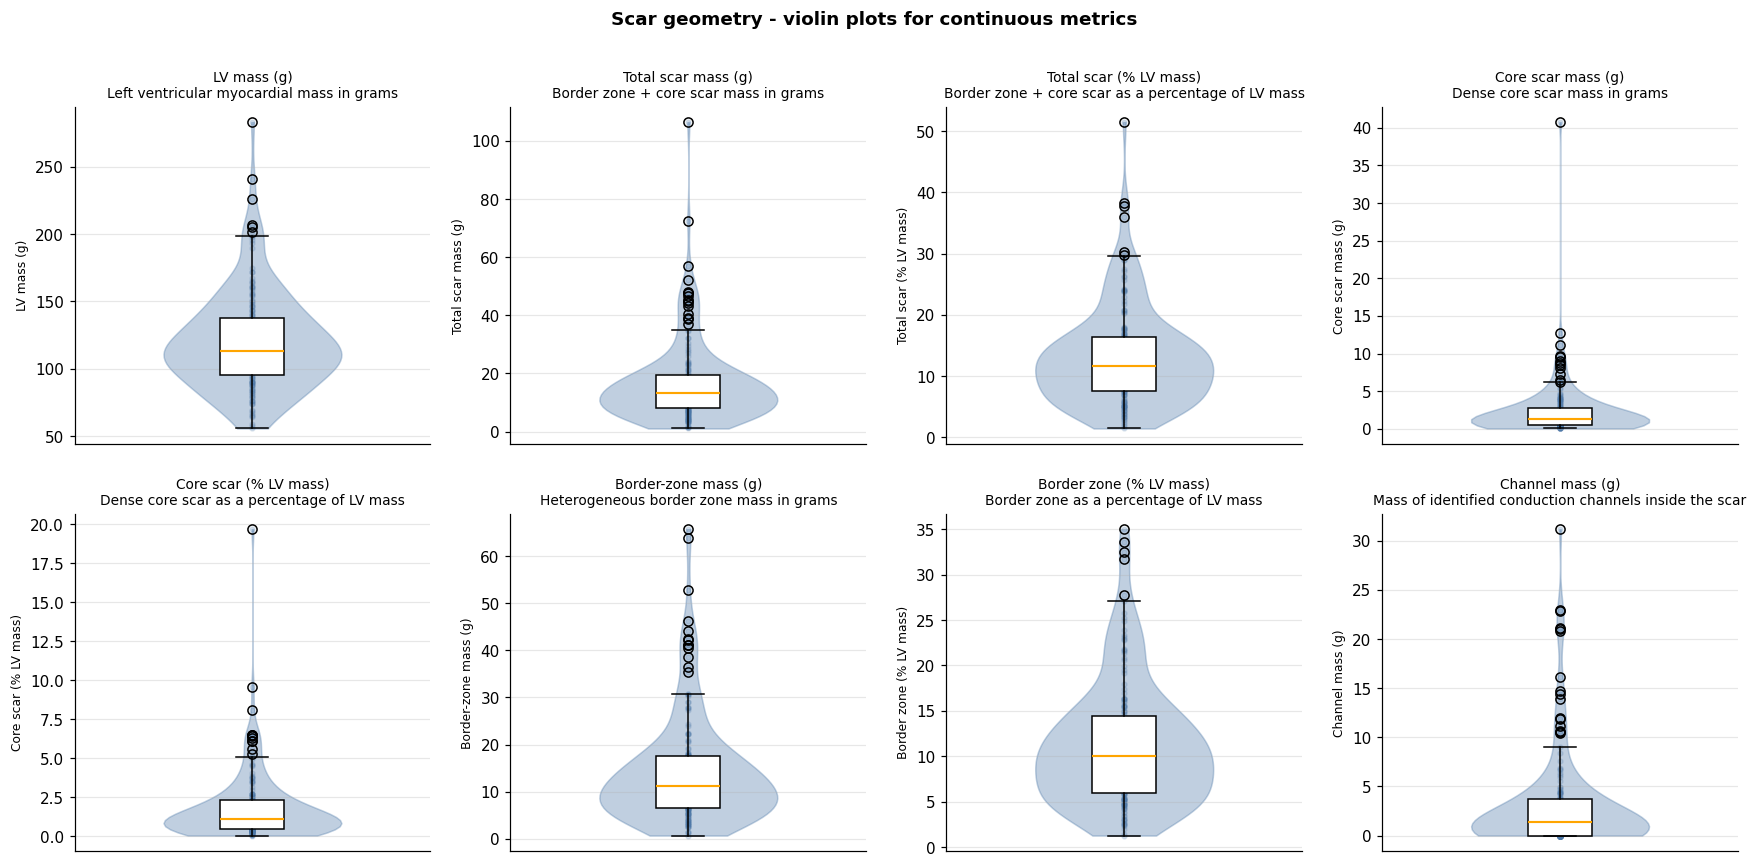

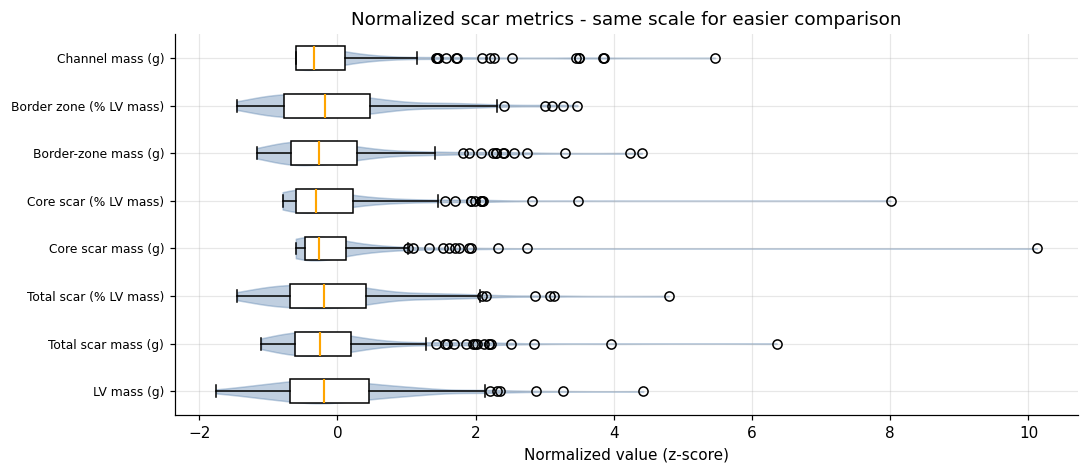

Descriptive statistics:


,lv_mass_g,bz_core_g,bz_core_pct,core_g,core_pct,bz_g,bz_pct,channel_mass_g
count,166.00,166.00,166.00,166.00,166.00,166.00,166.00,167.00
mean,120.24,16.64,13.05,2.33,1.81,14.33,11.25,3.10
std,36.82,14.14,8.02,3.80,2.24,11.66,6.85,5.14
min,55.54,1.04,1.42,0.04,0.04,0.70,1.26,0.00
25%,95.20,7.93,7.49,0.55,0.47,6.58,5.93,0.00
50%,112.96,13.14,11.55,1.30,1.10,11.30,9.98,1.40
75%,137.32,19.33,16.40,2.81,2.32,17.68,14.48,3.68
max,283.25,106.50,51.50,40.76,19.71,65.73,35.04,31.20


In [17]:
scar_num = [c for c in ['lv_mass_g', 'bz_core_g', 'bz_core_pct',
                         'core_g', 'core_pct', 'bz_g', 'bz_pct',
                         'channel_mass_g'] if c in df.columns]

n_cols = 4
n_rows = ceil(len(scar_num) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4.0 * n_rows))
axes = axes.flatten()

for i, col in enumerate(scar_num):
    vals = pd.to_numeric(df[col], errors='coerce').dropna()
    violin = axes[i].violinplot(vals, showmeans=False, showmedians=False, showextrema=False)
    for body in violin['bodies']:
        body.set_facecolor(HIST_COLOR)
        body.set_edgecolor(HIST_COLOR)
        body.set_alpha(0.35)
    axes[i].scatter(np.ones(len(vals)), vals, alpha=0.18, s=10, color=HIST_COLOR)
    axes[i].boxplot(vals, widths=0.18, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='white', edgecolor='black', linewidth=1.0),
                    medianprops=dict(color='orange', linewidth=1.4),
                    whiskerprops=dict(color='black'),
                    capprops=dict(color='black'))
    axes[i].set_title(variable_title(col), fontsize=9)
    axes[i].set_ylabel(variable_label(col), fontsize=8)
    axes[i].set_xticks([])

for ax in axes[len(scar_num):]:
    ax.set_visible(False)

plt.suptitle('Scar geometry - violin plots for continuous metrics', fontweight='bold')
plt.tight_layout(rect=(0, 0, 1, 0.97), h_pad=2.0, w_pad=1.4)
plt.savefig(RESULTS_DIR / '04a_scar_continuous.png', bbox_inches='tight')
plt.show()

norm_cols = [c for c in scar_num if df[c].notna().sum() >= 5 and float(pd.to_numeric(df[c], errors='coerce').std()) > 0]
if norm_cols:
    fig, ax = plt.subplots(figsize=(10, max(4, 0.55 * len(norm_cols))))
    data = [zscore(df[c]).dropna().values for c in norm_cols]
    violin = ax.violinplot(data, vert=False, showmeans=False, showmedians=False, showextrema=False)
    for body in violin['bodies']:
        body.set_facecolor(HIST_COLOR)
        body.set_edgecolor(HIST_COLOR)
        body.set_alpha(0.35)
    bp = ax.boxplot(data, vert=False, patch_artist=True,
                    medianprops=dict(color='orange', linewidth=1.4),
                    boxprops=dict(facecolor='white', edgecolor='black', linewidth=1.0),
                    whiskerprops=dict(color='black'),
                    capprops=dict(color='black'))
    ax.set_yticklabels([variable_label(c) for c in norm_cols], fontsize=8)
    ax.set_xlabel('Normalized value (z-score)')
    ax.set_title('Normalized scar metrics - same scale for easier comparison')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / '04a_scar_continuous_normalized.png', bbox_inches='tight')
    plt.show()

print('Descriptive statistics:')
display(df[scar_num].describe().round(2))


### 4b · Categorical scar variables

First, print raw unique values so we understand what is actually stored.
Then plot, applying keyword simplification to `enhancement_territory`.

> **Note on enhancement_distribution:** stored as numeric codes (1, 2, 3 …). Meaning unknown — ask the clinical team for the coding legend.

In [18]:
for col in ['enhancement_territory', 'enhancement_distribution',
            'enhancement_grade', 'channels', 'mri_type']:
    if col in df.columns:
        print(f'--- {col} ({df[col].notna().sum()} non-null) ---')
        print(df[col].value_counts(dropna=False).to_string())
        print()

--- enhancement_territory (89 non-null) ---
enhancement_territory
NaN                                                                                                                                                                                                                                                                                 84
Anterior-anteroseptal medio y apical                                                                                                                                                                                                                                                 1
Pared inferior e inferoseptal medio-basal                                                                                                                                                                                                                                            1
Subendo en segmentos inferolaterales medio-apicales, captación pequeña en papilar PM             

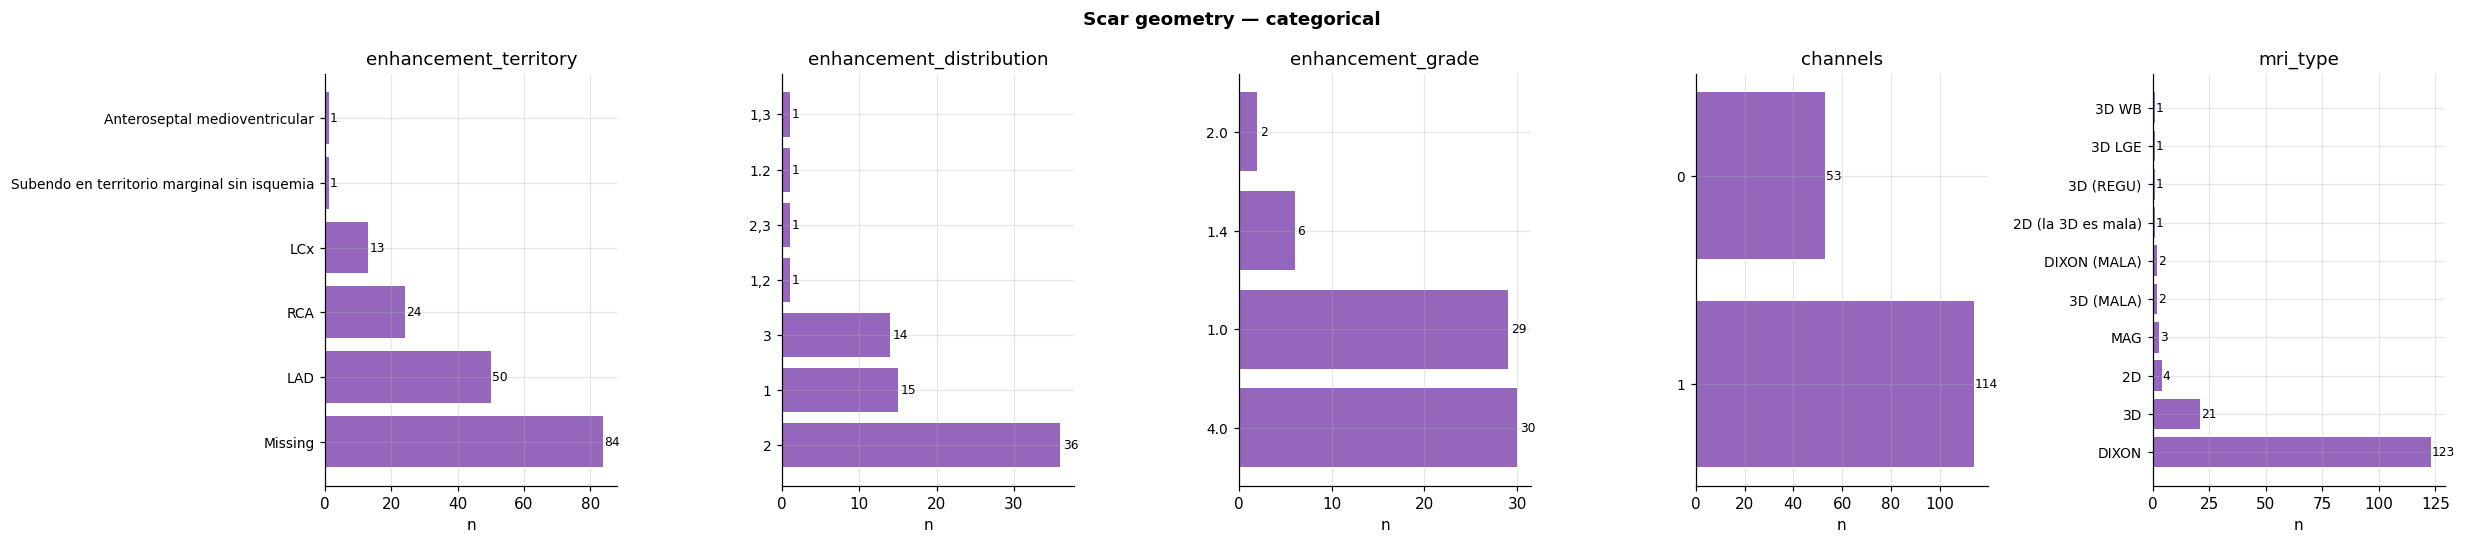

In [19]:
def simplify_territory(val):
    if pd.isna(val):
        return 'Missing'
    v = str(val).upper()
    if 'LAD' in v or 'ANTERIOR' in v or 'APICAL' in v:
        return 'LAD'
    if 'RCA' in v or 'INFERIOR' in v or 'INFEROSEPTAL' in v:
        return 'RCA'
    if 'LCX' in v or 'LATERAL' in v or 'CIRCUMFLEX' in v or 'CIRCUNFLEJA' in v:
        return 'LCx'
    if 'MULTI' in v or 'BIVAS' in v or 'TRIVAS' in v or 'DA+' in v or '+CD' in v:
        return 'Multi-vessel'
    return str(val)

cat_cols = [c for c in ['enhancement_territory', 'enhancement_distribution',
                         'enhancement_grade', 'channels', 'mri_type']
            if c in df.columns]

if cat_cols:
    fig, axes = plt.subplots(1, len(cat_cols), figsize=(4.5 * len(cat_cols), 5))
    if len(cat_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, cat_cols):
        if col == 'enhancement_territory':
            s = df[col].map(simplify_territory)
        else:
            s = df[col].dropna().astype(str)
        vc = s.value_counts().head(10)
        ax.barh(vc.index, vc.values, color=PAL[4])
        for y_pos, (label, val) in enumerate(zip(vc.index, vc.values)):
            ax.text(val + 0.3, y_pos, str(val), va='center', fontsize=8)
        ax.set_title(col)
        ax.set_xlabel('n')
        ax.tick_params(axis='y', labelsize=9)

    plt.suptitle('Scar geometry — categorical', fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / '04b_scar_categorical.png', bbox_inches='tight')
    plt.show()

## 5 · Echocardiography

Echocardiography is a **cardiac ultrasound** exam that measures heart structure and function without radiation. It is the standard tool for assessing ventricular size and systolic function.

### Variable glossary

| Variable | Full name | Meaning |
|---|---|---|
| **lvef_pct** | LV ejection fraction | % of blood pumped per beat. Normal ≥ 55 %. |
| **lvedd_mm** | LV end-diastolic diameter | Cavity width when the ventricle is relaxed (filled). |
| **lvesd_mm** | LV end-systolic diameter | Cavity width when the ventricle is contracted (emptied). |
| **lvedv_ml** | LV end-diastolic volume | Blood volume in LV at end of relaxation. |
| **lvesv_ml** | LV end-systolic volume | Blood volume remaining after contraction. |
| **lvedv_index** | LVEDV / BSA | LVEDV normalised by body surface area (mL/m²). |
| **lvesv_index** | LVESV / BSA | LVESV normalised by body surface area (mL/m²). |
| **la_mm** | Left atrium diameter | LA size — enlarges in AF and heart failure. |
| **septum_mm** | Septal thickness | Thickness of the wall between the two ventricles. |
| **post_wall_mm** | Posterior wall thickness | Thickness of the LV posterior wall. |

> Echo data is available for ~50 % of patients. Scatter plots relating echo to scar are deferred until a specific clinically motivated question is defined.

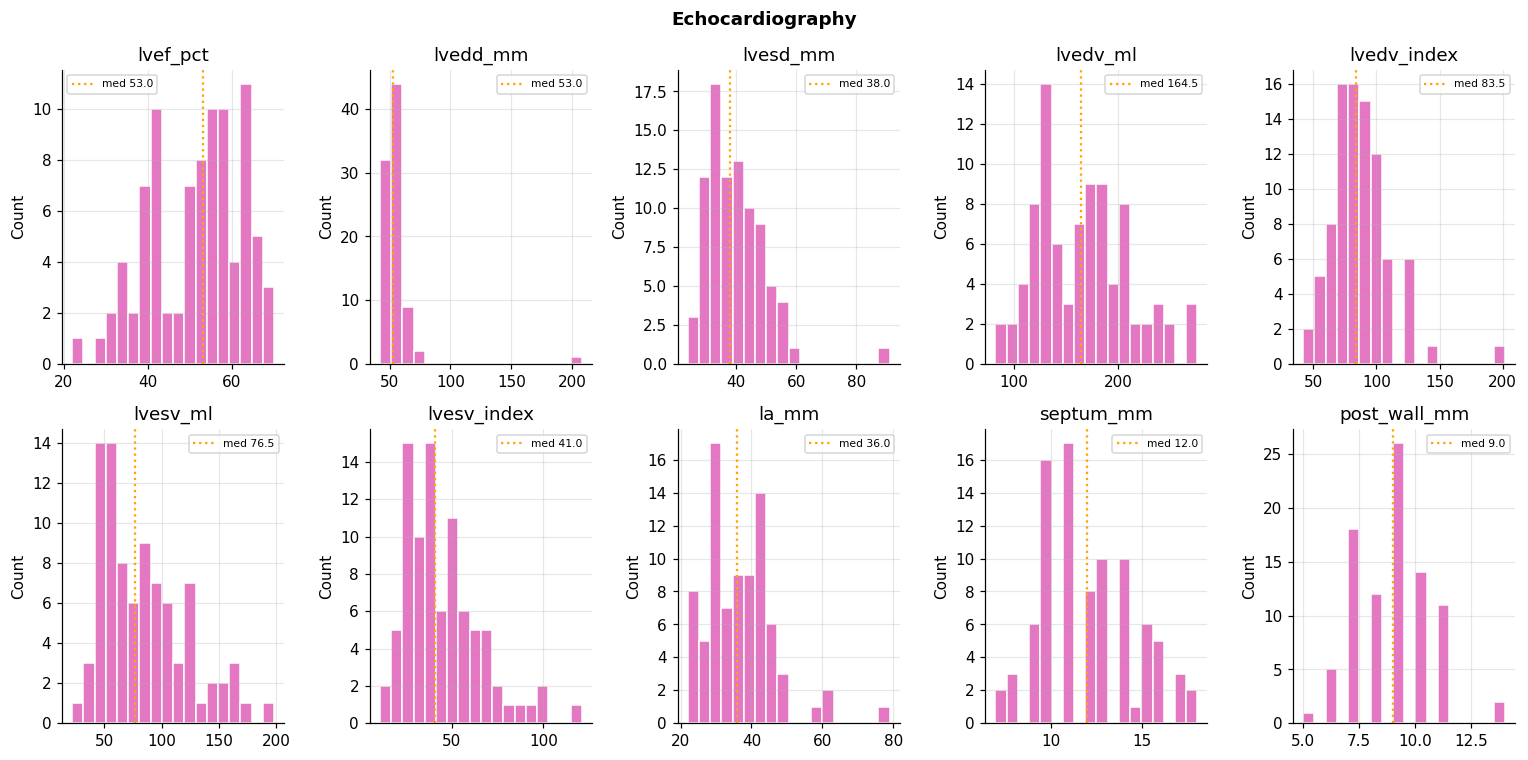

Descriptive statistics:


,lvef_pct,lvedd_mm,lvesd_mm,lvedv_ml,lvedv_index,lvesv_ml,lvesv_index,la_mm,septum_mm,post_wall_mm
count,89.00,88.00,88.00,88.00,88.00,88.00,88.00,82.00,89.00,89.00
mean,51.24,55.38,39.94,166.02,87.68,85.09,44.99,36.87,12.10,8.76
std,10.94,17.71,9.66,44.35,23.14,37.24,20.13,9.74,2.54,1.68
min,22.00,42.00,24.00,82.00,42.00,22.00,11.00,22.00,7.00,5.00
25%,42.00,49.75,33.00,129.75,74.00,57.75,29.75,30.00,10.00,7.00
50%,53.00,53.00,38.00,164.50,83.50,76.50,41.00,36.00,12.00,9.00
75%,60.00,57.00,45.00,192.25,99.25,104.50,55.25,42.00,14.00,10.00
max,70.00,208.00,91.00,276.00,202.00,198.00,121.00,79.00,18.00,14.00


In [20]:
echo_cols = [c for c in COLUMN_GROUPS['echo'] if c in df.columns]

n_cols = 5
n_rows = ceil(len(echo_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(echo_cols):
    s = df[col].dropna()
    axes[i].hist(s, bins=18, color=PAL[6], edgecolor='white')
    axes[i].axvline(float(s.median()), color='orange', linestyle=':',
                    label=f'med {float(s.median()):.1f}')
    axes[i].set_title(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=7)

for ax in axes[len(echo_cols):]:
    ax.set_visible(False)

plt.suptitle('Echocardiography', fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / '05_echo.png', bbox_inches='tight')
plt.show()

print('Descriptive statistics:')
display(df[echo_cols].describe().round(2))

## 6 · Correlation matrix — all numeric variables

Pearson r for every numeric column with ≥ 20 non-null values.
The matrix is **symmetric** (r(A,B) = r(B,A)).
Only cells with |r| ≥ 0.3 are annotated to keep the plot readable.
Pairs with fewer than 10 shared observations are left blank (NaN).

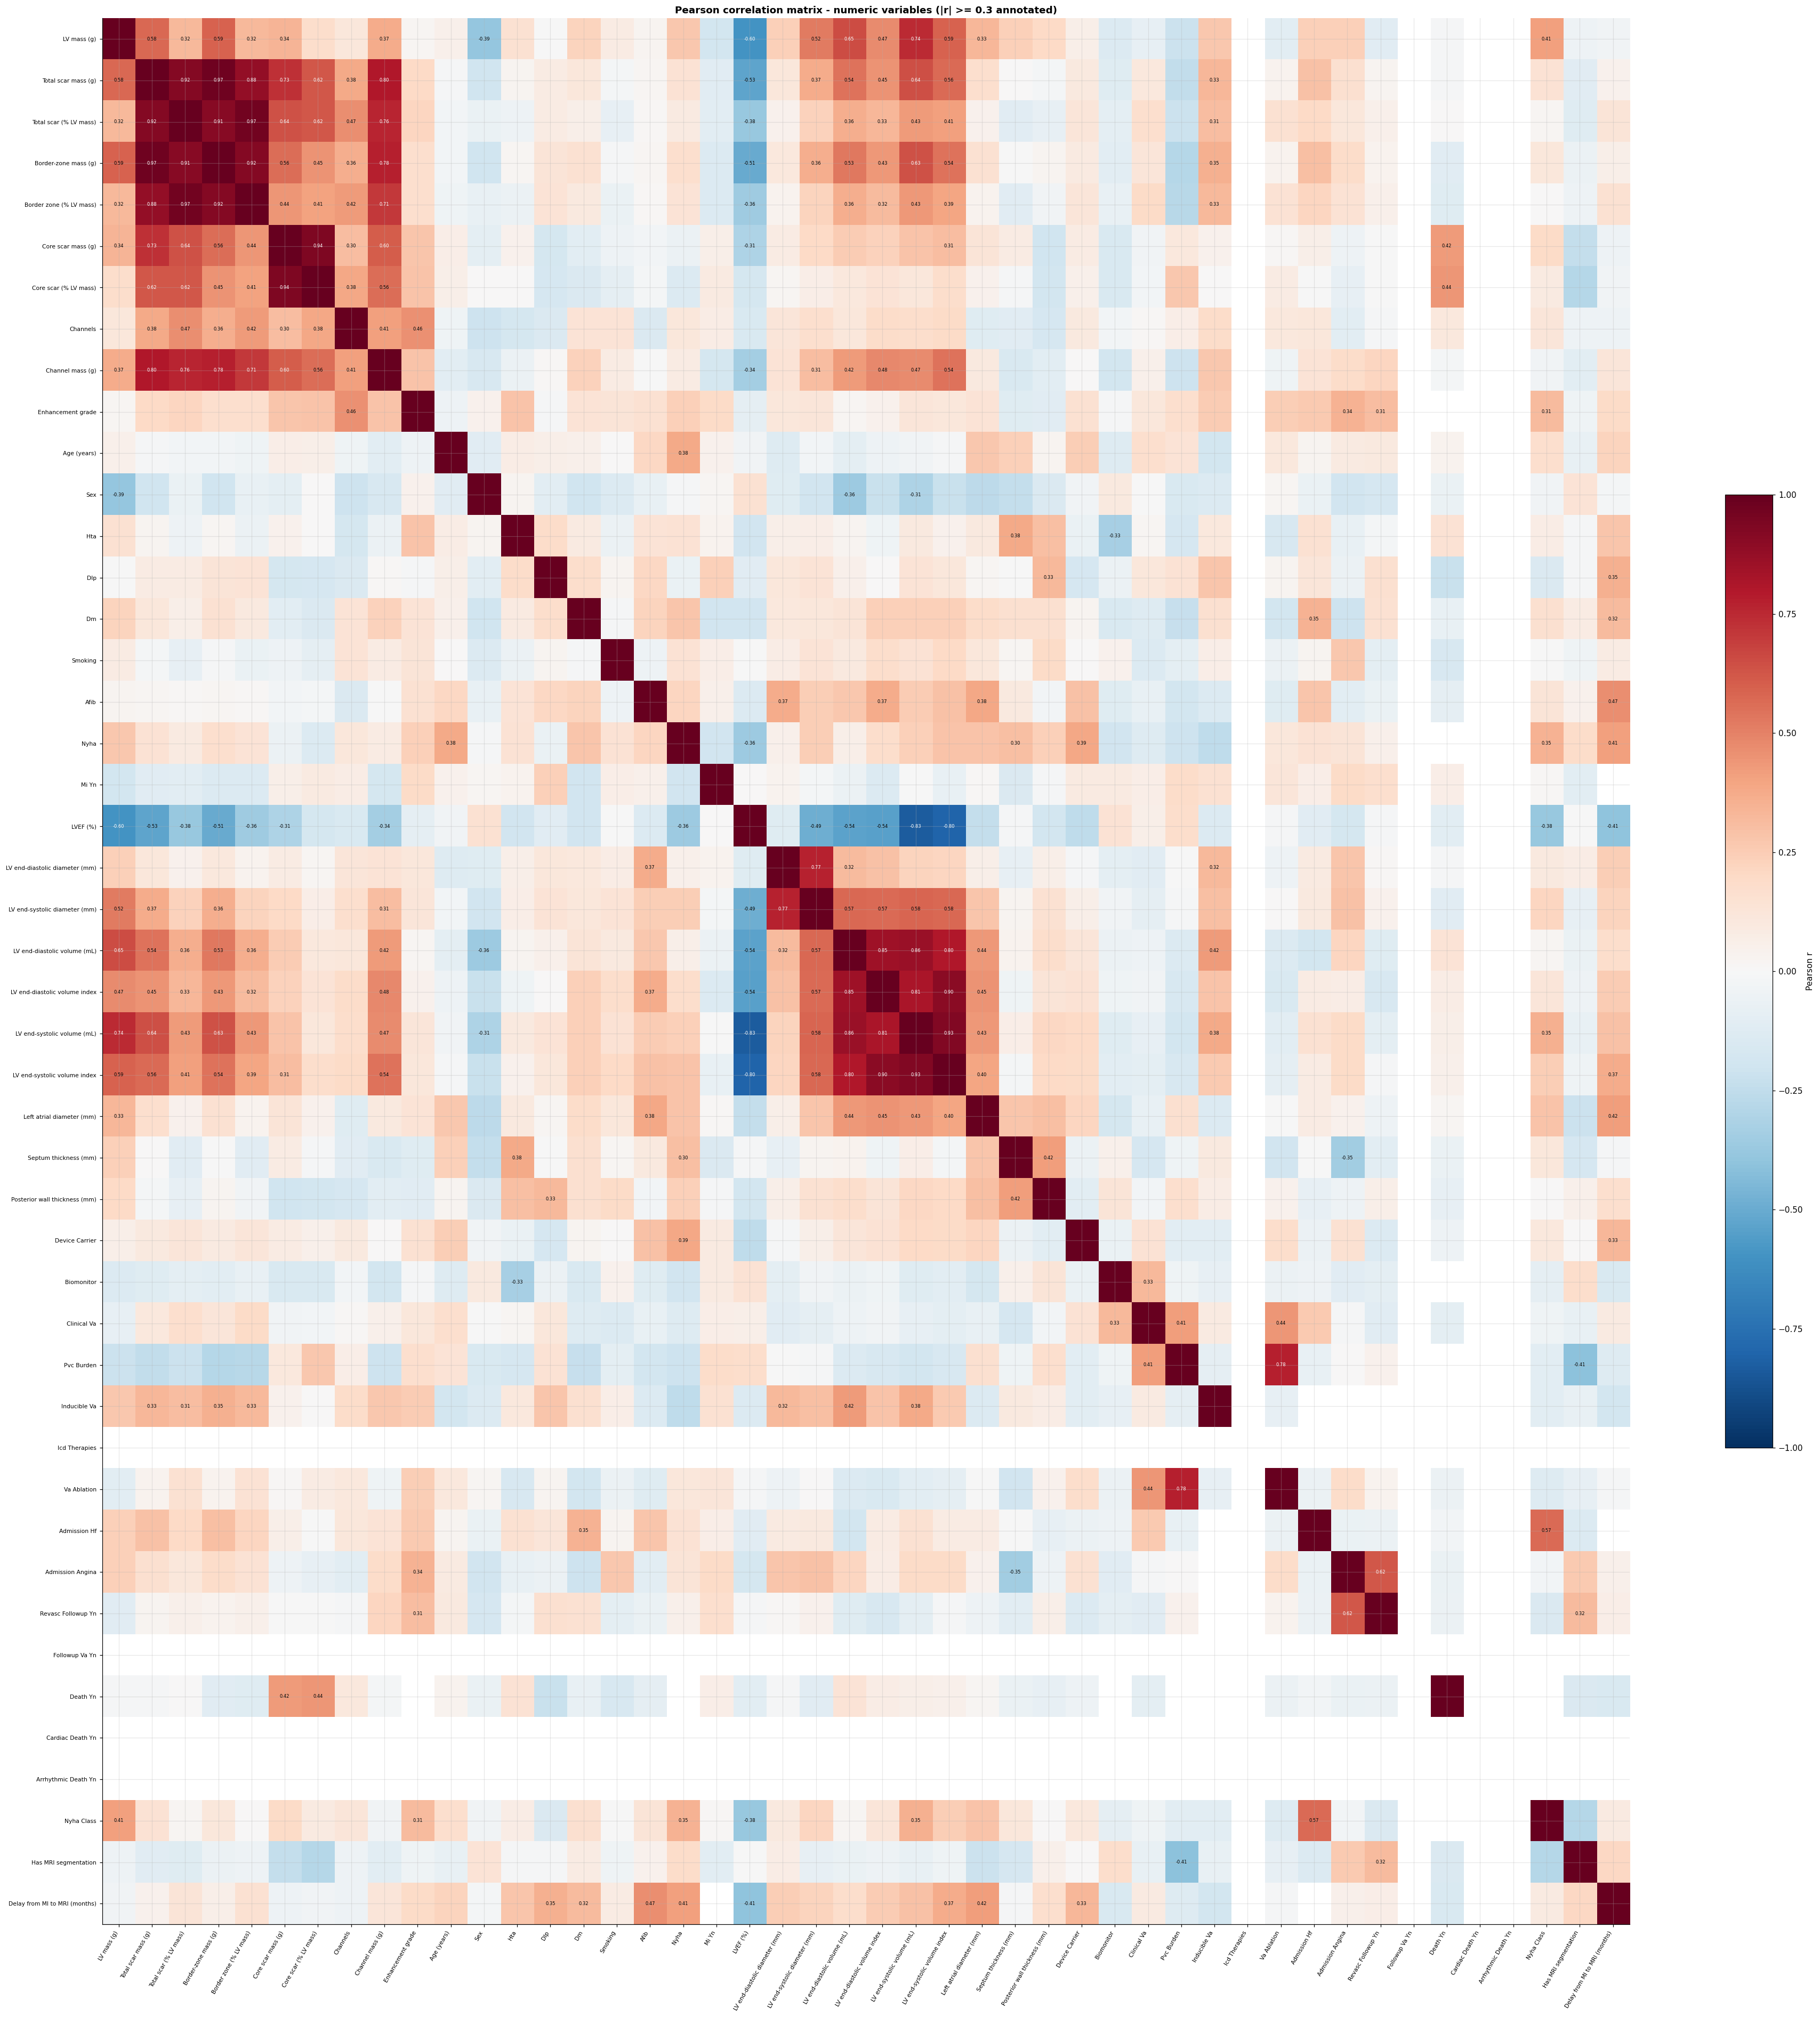

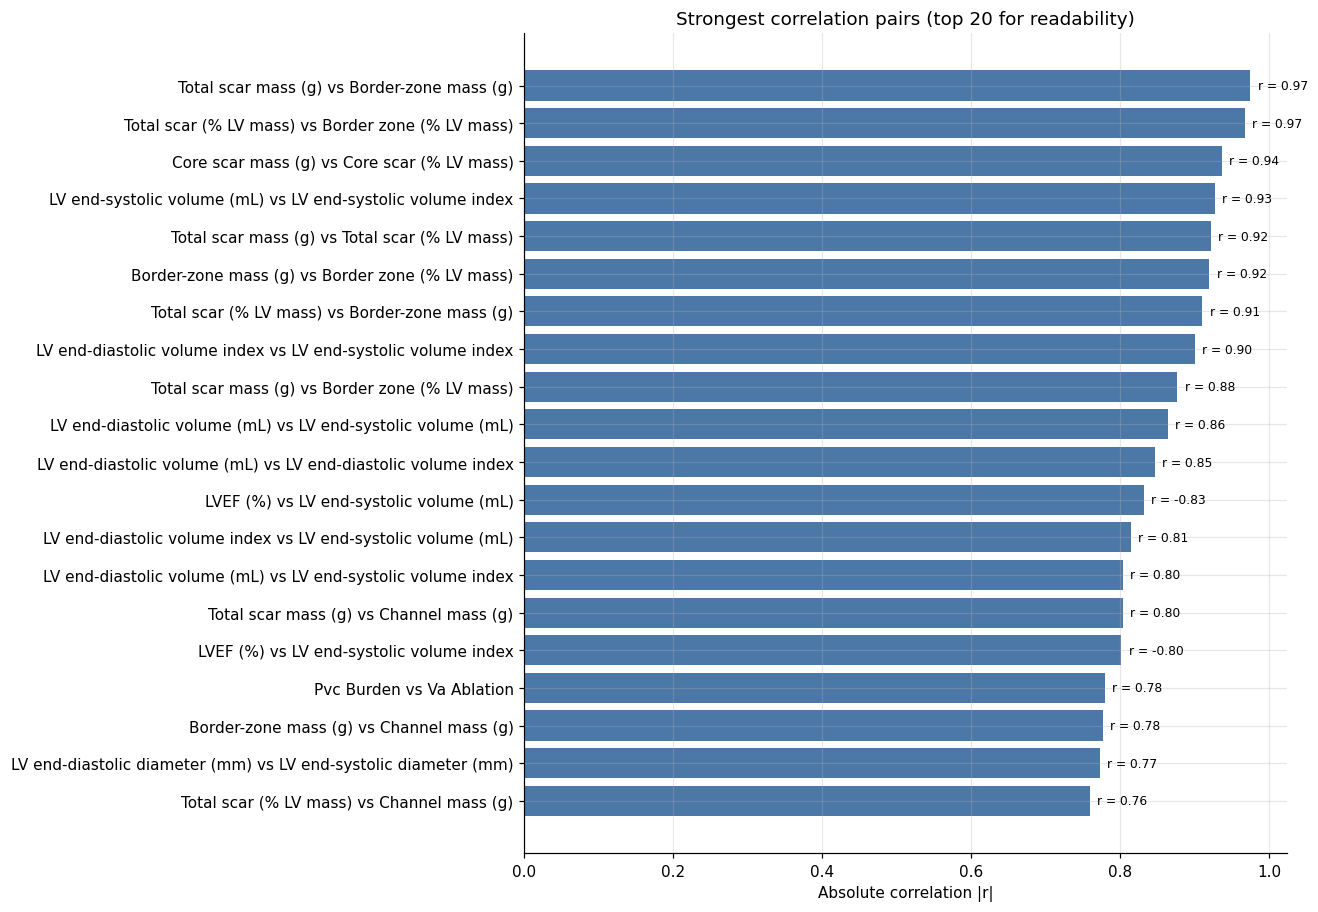

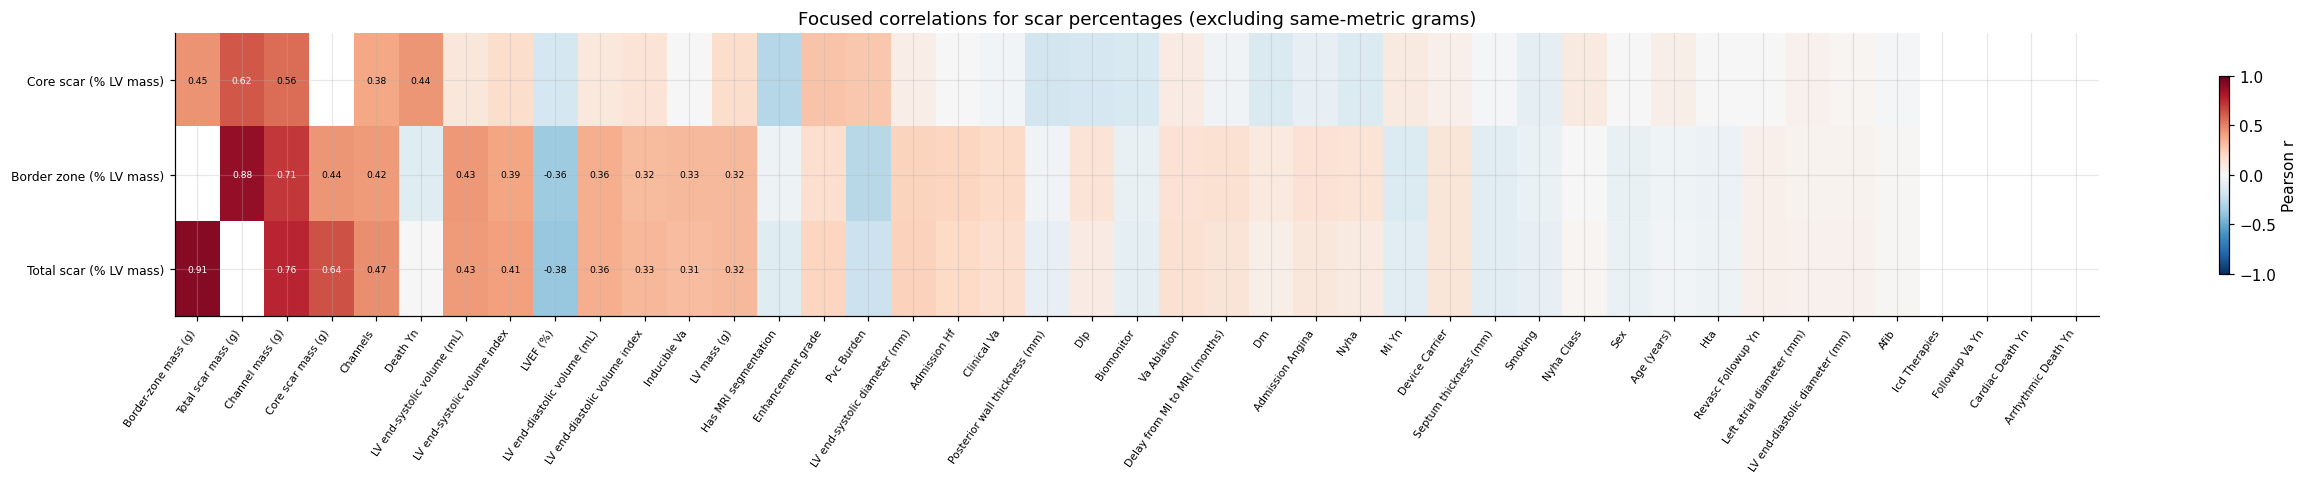

Focused correlations for scar percentage metrics:


,Scar % metric,Related variable,Meaning,r,abs_r
0,Border zone (% LV mass),Total scar mass (g),Border zone + core scar mass in grams,0.876687,0.876687
1,Border zone (% LV mass),Channel mass (g),Mass of identified conduction channels inside ...,0.706760,0.706760
2,Border zone (% LV mass),Core scar mass (g),Dense core scar mass in grams,0.439543,0.439543
3,Border zone (% LV mass),LV end-systolic volume (mL),LV volume at end-systole,0.430532,0.430532
4,Border zone (% LV mass),Channels,1 = conduction channels identified within the ...,0.424107,0.424107
5,Border zone (% LV mass),LV end-systolic volume index,Indexed LV end-systolic volume,0.393762,0.393762
6,Border zone (% LV mass),LV end-diastolic volume (mL),LV volume at end-diastole,0.360681,0.360681
7,Border zone (% LV mass),LVEF (%),Left ventricular ejection fraction,-0.357034,0.357034
8,Border zone (% LV mass),Inducible Va,,0.327846,0.327846
9,Border zone (% LV mass),LV mass (g),Left ventricular myocardial mass in grams,0.320532,0.320532


All numeric-variable pairwise correlations sorted by absolute value:


,Variable A,Meaning A,Variable B,Meaning B,r,abs_r
0,Total scar mass (g),Border zone + core scar mass in grams,Border-zone mass (g),Heterogeneous border zone mass in grams,0.974888,0.974888
1,Total scar (% LV mass),Border zone + core scar as a percentage of LV ...,Border zone (% LV mass),Border zone as a percentage of LV mass,0.967159,0.967159
2,Core scar mass (g),Dense core scar mass in grams,Core scar (% LV mass),Dense core scar as a percentage of LV mass,0.936605,0.936605
3,LV end-systolic volume (mL),LV volume at end-systole,LV end-systolic volume index,Indexed LV end-systolic volume,0.927144,0.927144
4,Total scar mass (g),Border zone + core scar mass in grams,Total scar (% LV mass),Border zone + core scar as a percentage of LV ...,0.921510,0.921510
...,...,...,...,...,...,...
2111,Va Ablation,,Sex,"Registry code: 1 = male, 2 = female",NaN,NaN
2112,Va Ablation,,Smoking,,NaN,NaN
2113,Va Ablation,,Total scar (% LV mass),Border zone + core scar as a percentage of LV ...,NaN,NaN
2114,Va Ablation,,Total scar mass (g),Border zone + core scar mass in grams,NaN,NaN


In [21]:
all_num = [
    c for c in df.columns
    if pd.api.types.is_numeric_dtype(df[c])
    and df[c].notna().sum() >= 20
    and c not in ('patient_id', 'patient_id_norm')
]

corr = (
    df[all_num]
    .apply(pd.to_numeric, errors='coerce')
    .corr(method='pearson', min_periods=10)
)

short_labels = [variable_label(c) for c in all_num]
sz = max(12, len(all_num) * 0.75)
fig, ax = plt.subplots(figsize=(sz, sz))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(all_num)))
ax.set_xticklabels(short_labels, rotation=60, ha='right', fontsize=7)
ax.set_yticks(range(len(all_num)))
ax.set_yticklabels(short_labels, fontsize=7)
plt.colorbar(im, ax=ax, label='Pearson r', shrink=0.5)

for i in range(len(all_num)):
    for j in range(len(all_num)):
        v = corr.iloc[i, j]
        if not np.isnan(v) and abs(v) >= 0.3 and i != j:
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    fontsize=5.5,
                    color='black' if abs(v) < 0.6 else 'white')

ax.set_title('Pearson correlation matrix - numeric variables (|r| >= 0.3 annotated)',
             fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / '06_correlation.png', bbox_inches='tight')
plt.show()

mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)
all_pairs = corr.where(mask).stack().reset_index()
all_pairs.columns = ['var_a', 'var_b', 'r']
all_pairs['abs_r'] = all_pairs['r'].abs()
all_pairs['Variable A'] = all_pairs['var_a'].map(variable_label)
all_pairs['Variable B'] = all_pairs['var_b'].map(variable_label)
all_pairs['Meaning A'] = all_pairs['var_a'].map(variable_description)
all_pairs['Meaning B'] = all_pairs['var_b'].map(variable_description)
all_pairs = all_pairs.sort_values(['abs_r', 'Variable A', 'Variable B'], ascending=[False, True, True]).reset_index(drop=True)

plot_pairs = all_pairs.head(min(20, len(all_pairs))).copy()
fig, ax = plt.subplots(figsize=(12, max(5, 0.42 * len(plot_pairs))))
ylabels = [f"{a} vs {b}" for a, b in zip(plot_pairs['Variable A'], plot_pairs['Variable B'])]
ax.barh(ylabels[::-1], plot_pairs['abs_r'].iloc[::-1], color=HIST_COLOR)
for i, r in enumerate(plot_pairs['r'].iloc[::-1]):
    ax.text(abs(r) + 0.01, i, f'r = {r:.2f}', va='center', fontsize=8)
ax.set_xlabel('Absolute correlation |r|')
ax.set_title('Strongest correlation pairs (top 20 for readability)')
plt.tight_layout()
plt.savefig(RESULTS_DIR / '06_top_correlations.png', bbox_inches='tight')
plt.show()

scar_pct_focus = [c for c in ['core_pct', 'bz_pct', 'bz_core_pct'] if c in corr.index]
scar_pct_exclude = {
    'core_pct': {'core_pct', 'core_g'},
    'bz_pct': {'bz_pct', 'bz_g'},
    'bz_core_pct': {'bz_core_pct', 'bz_core_g'},
}

if scar_pct_focus:
    focus_cols = [
        c for c in all_num
        if c not in scar_pct_focus
        and any(c not in scar_pct_exclude[row] for row in scar_pct_focus)
    ]
    focus_vals = pd.DataFrame(index=scar_pct_focus, columns=focus_cols, dtype=float)
    for row in scar_pct_focus:
        allowed_cols = [c for c in focus_cols if c not in scar_pct_exclude[row]]
        focus_vals.loc[row, allowed_cols] = corr.loc[row, allowed_cols]

    focus_scores = focus_vals.abs().max(axis=0).fillna(-1)
    focus_cols_sorted = focus_scores.sort_values(ascending=False).index.tolist()
    focus_vals = focus_vals[focus_cols_sorted]

    fig, ax = plt.subplots(figsize=(max(11, 0.55 * len(focus_cols_sorted)), 4.5))
    im = ax.imshow(focus_vals.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(len(focus_cols_sorted)))
    ax.set_xticklabels([variable_label(c) for c in focus_cols_sorted], rotation=55, ha='right', fontsize=7)
    ax.set_yticks(range(len(scar_pct_focus)))
    ax.set_yticklabels([variable_label(c) for c in scar_pct_focus], fontsize=8)
    plt.colorbar(im, ax=ax, label='Pearson r', shrink=0.7)
    for i in range(len(scar_pct_focus)):
        for j in range(len(focus_cols_sorted)):
            v = focus_vals.iloc[i, j]
            if not np.isnan(v) and abs(v) >= 0.3:
                ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                        fontsize=6,
                        color='black' if abs(v) < 0.6 else 'white')
    ax.set_title('Focused correlations for scar percentages (excluding same-metric grams)')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / '06_scar_pct_focus_correlation.png', bbox_inches='tight')
    plt.show()

    focus_pairs = []
    for row in scar_pct_focus:
        row_series = focus_vals.loc[row].dropna().abs().sort_values(ascending=False)
        for col in row_series.index:
            focus_pairs.append({
                'Scar % metric': variable_label(row),
                'Related variable': variable_label(col),
                'Meaning': variable_description(col),
                'r': float(corr.loc[row, col]),
                'abs_r': float(abs(corr.loc[row, col])),
            })
    focus_pairs_df = pd.DataFrame(focus_pairs).sort_values(
        ['Scar % metric', 'abs_r', 'Related variable'],
        ascending=[True, False, True]
    ).reset_index(drop=True)
    print('Focused correlations for scar percentage metrics:')
    display(focus_pairs_df)
    focus_pairs_df.to_csv(RESULTS_DIR / '06_scar_pct_focus_correlations.csv', index=False)

print('All numeric-variable pairwise correlations sorted by absolute value:')
display(all_pairs[['Variable A', 'Meaning A', 'Variable B', 'Meaning B', 'r', 'abs_r']])
all_pairs[['Variable A', 'Meaning A', 'Variable B', 'Meaning B', 'r', 'abs_r']].to_csv(RESULTS_DIR / '06_all_correlations_sorted.csv', index=False)


## 7 - Subgroup comparisons

We compare scar burden across clinical groups and also check practical age and LV-size questions.

Notes:
1. Age groups are defined from the dataset itself using tertiles (`pd.qcut`), so `Younger`, `Middle`, and `Older` are data-driven groups with similar patient counts.
2. `_pct` variables are already normalized by LV mass, while `_g` variables are absolute scar mass in grams.
3. To study age in more detail, we now plot total scar mass, core scar mass, and border-zone scar mass directly against age.


Age groups used in the plots (dataset tertiles):


,age_group_interval,n_patients
0,"(30.999, 61.0]",34
1,"(61.0, 68.667]",29
2,"(68.667, 84.0]",32


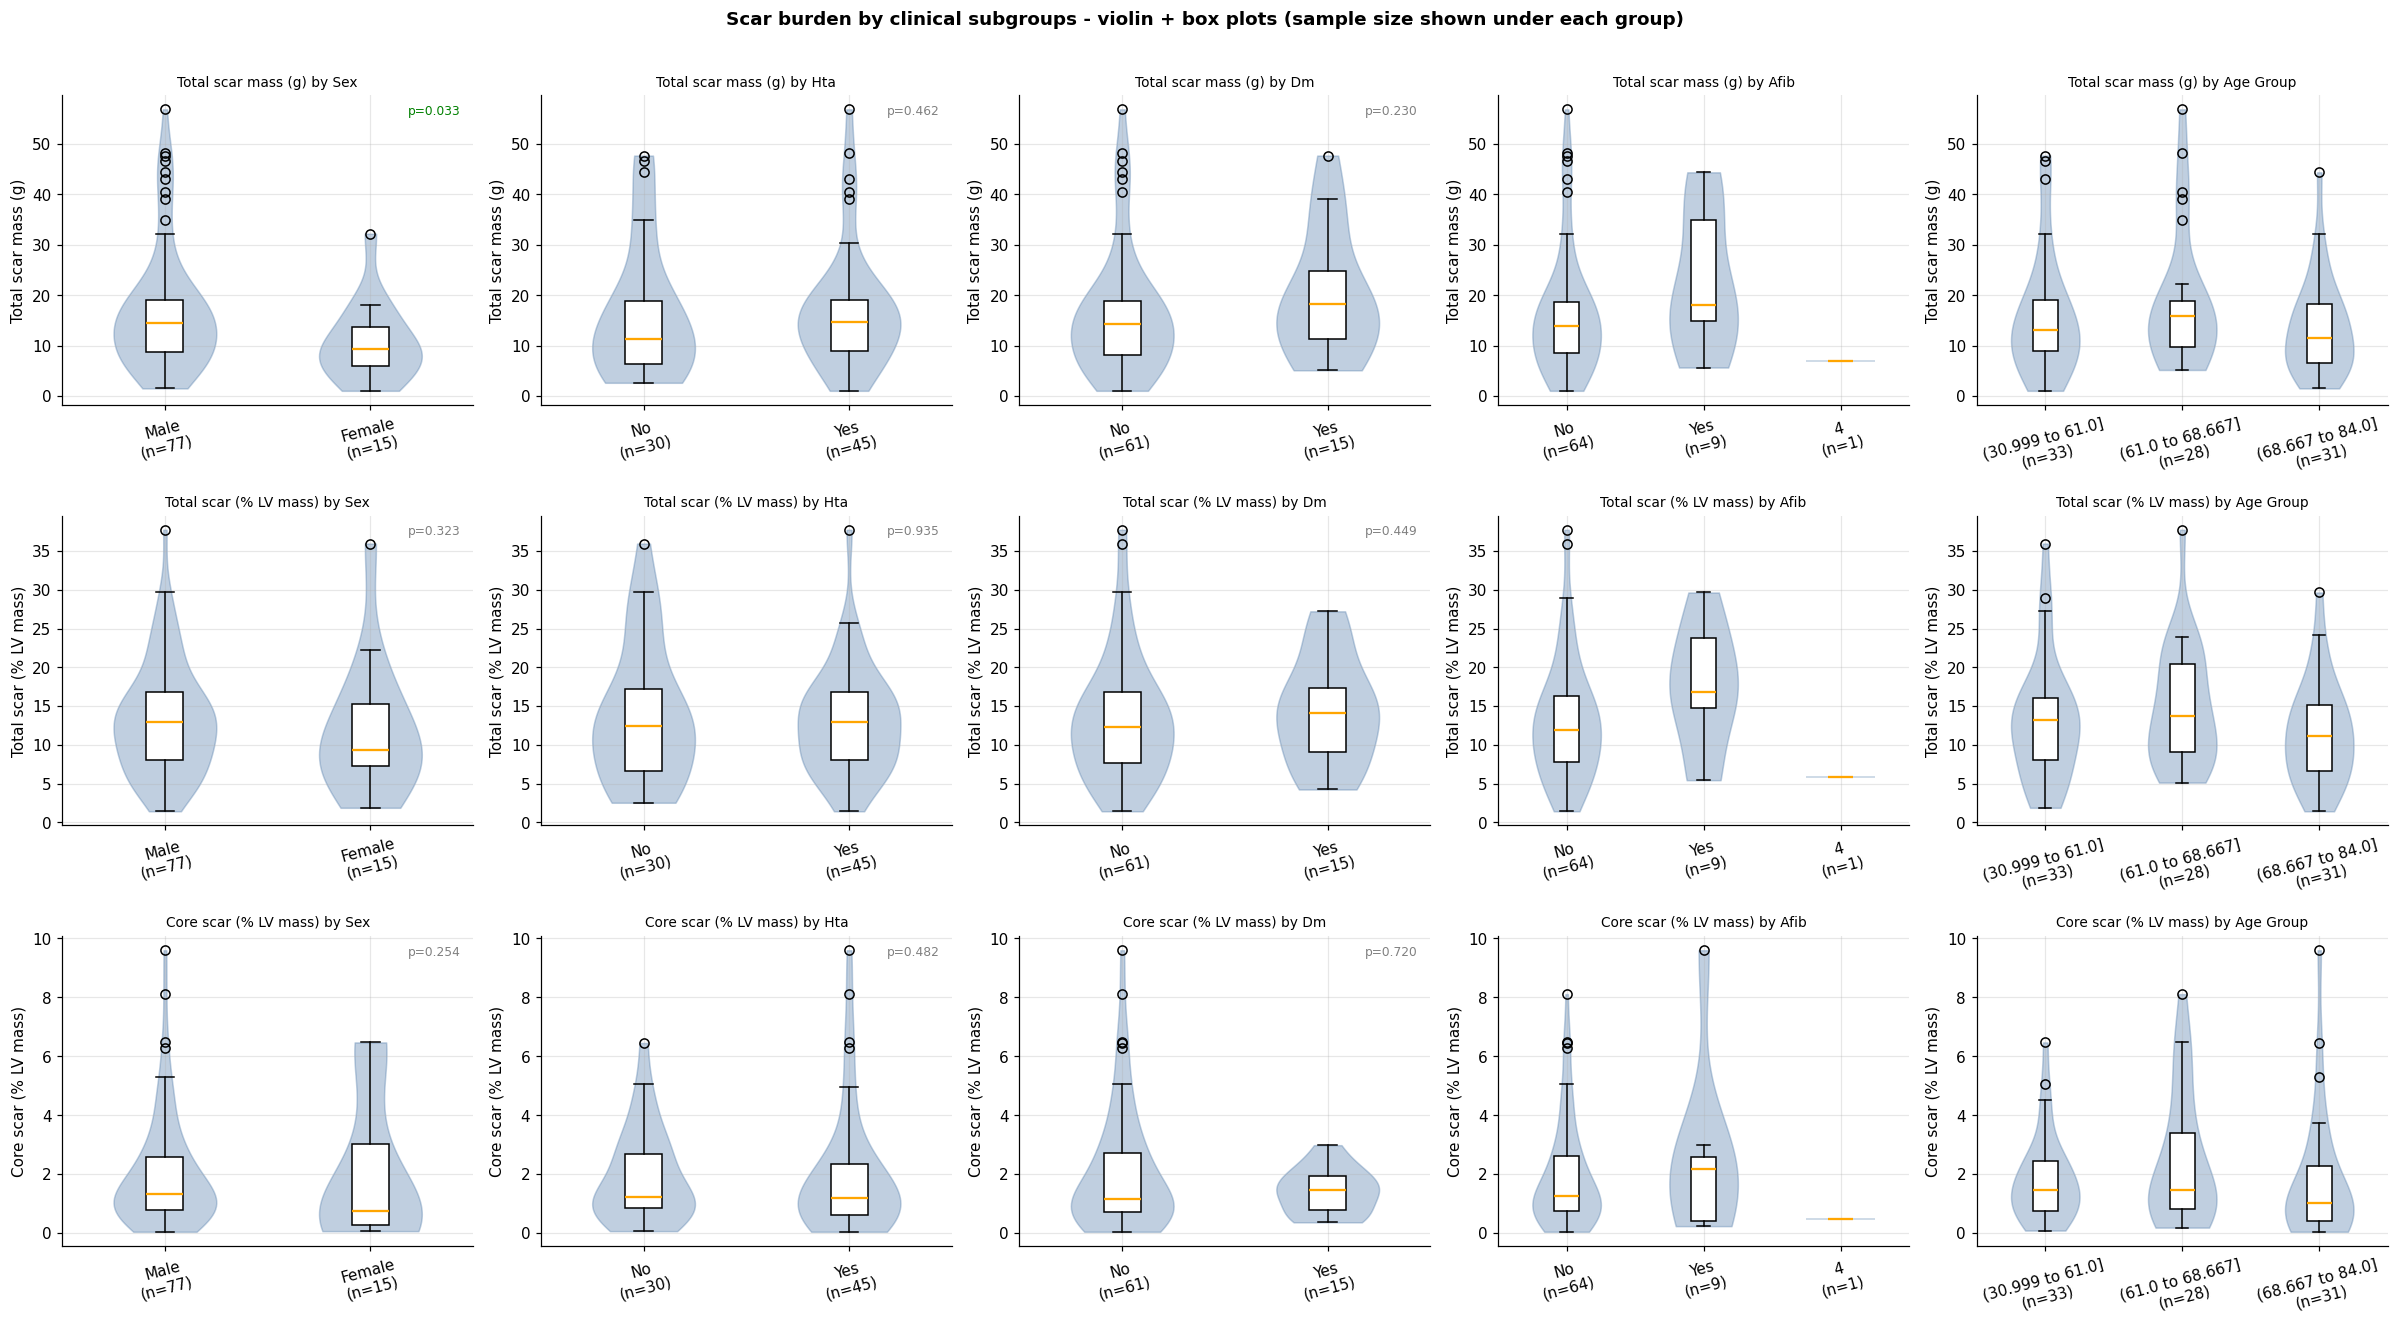

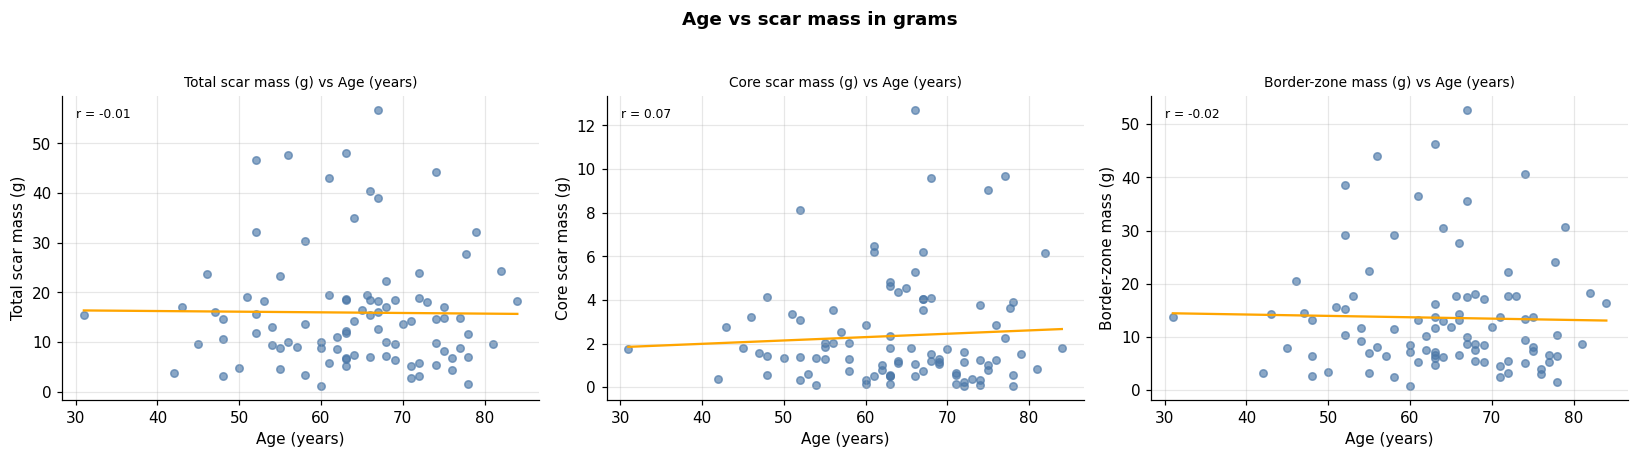

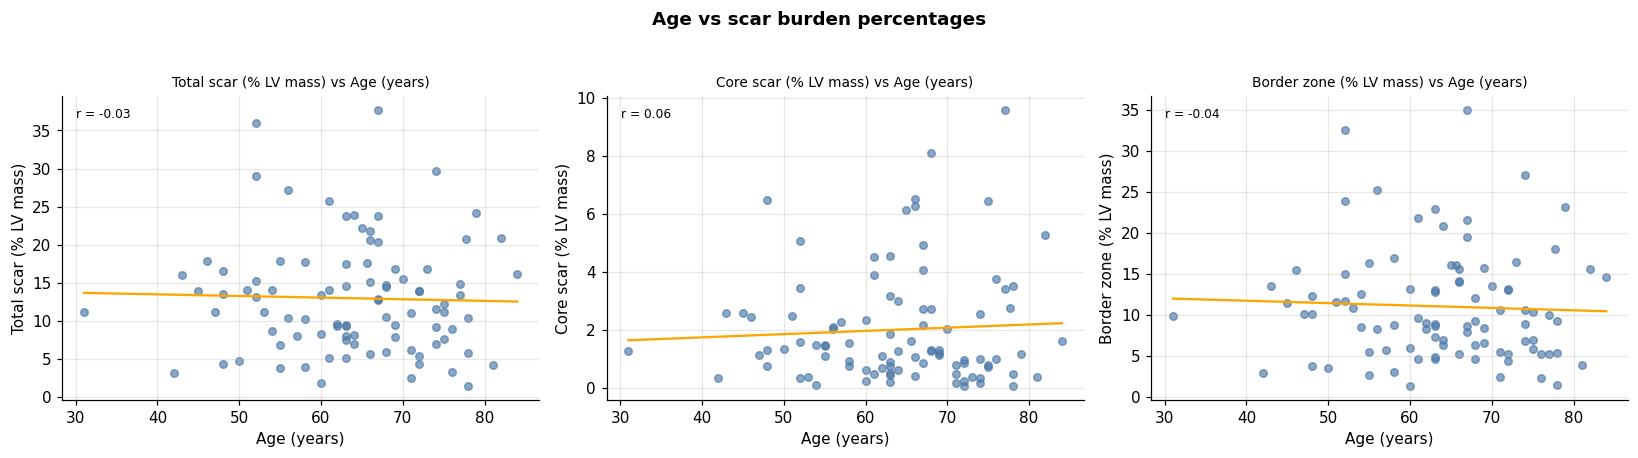

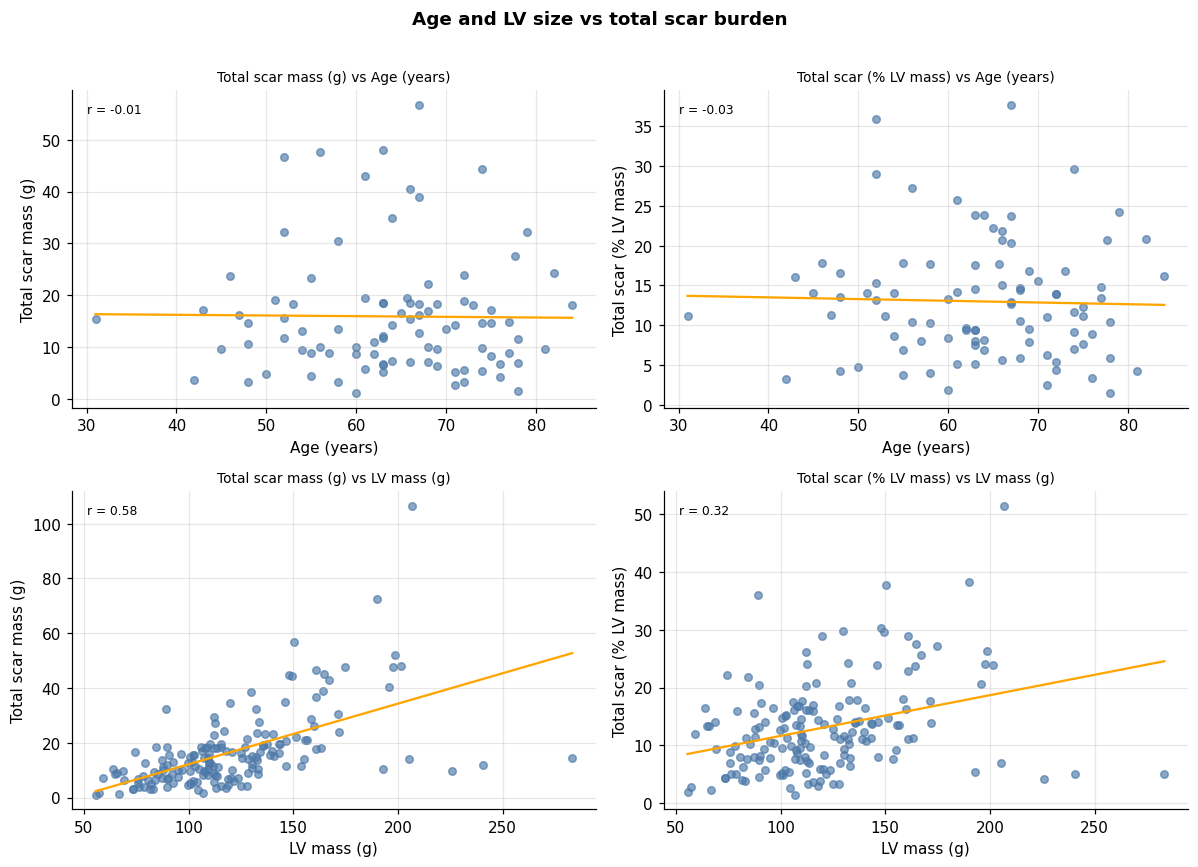

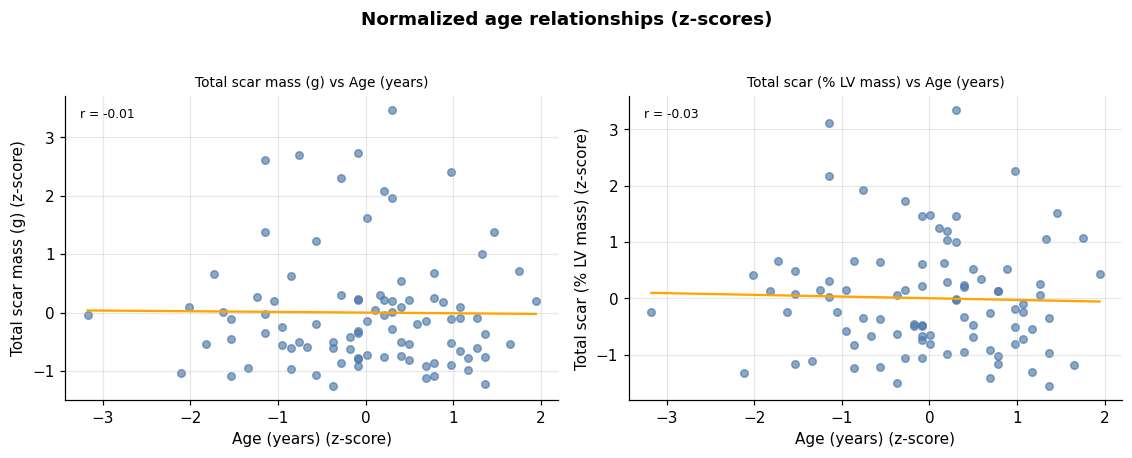

In [22]:
def boxplot_group(df, group_col, value_col, labels=None, ax=None, violin=False):
    sub = df[[group_col, value_col]].dropna()
    groups = sorted(sub[group_col].unique())
    data = [sub.loc[sub[group_col] == g, value_col].values for g in groups]
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))
    if not groups:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        return ax
    positions = np.arange(1, len(groups) + 1)
    if violin:
        violin_parts = ax.violinplot(data, positions=positions, showmeans=False, showmedians=False, showextrema=False)
        for body in violin_parts['bodies']:
            body.set_facecolor(HIST_COLOR)
            body.set_edgecolor(HIST_COLOR)
            body.set_alpha(0.35)
    ax.boxplot(data, positions=positions, widths=0.18, patch_artist=True,
               medianprops=dict(color='orange', linewidth=1.5),
               boxprops=dict(facecolor='white', edgecolor='black', linewidth=1.0),
               whiskerprops=dict(color='black'),
               capprops=dict(color='black'))
    tick_labels = []
    for g, vals in zip(groups, data):
        base_label = (labels or {}).get(g, str(g))
        tick_labels.append(f'{base_label}\n(n={len(vals)})')
    ax.set_xticks(positions)
    ax.set_xticklabels(tick_labels, rotation=15)
    ax.set_ylabel(variable_label(value_col))
    ax.set_title(f'{variable_label(value_col)} by {variable_label(group_col)}', fontsize=9)
    if len(data) == 2 and min(len(d) for d in data) > 0:
        _, p = stats.mannwhitneyu(data[0], data[1], alternative='two-sided')
        ax.text(0.97, 0.97, f'p={p:.3f}', transform=ax.transAxes,
                ha='right', va='top', fontsize=8,
                color='green' if p < 0.05 else 'grey')
    return ax


def relation_plot(df, x_col, y_col, ax, normalized=False):
    sub = df[[x_col, y_col]].dropna().copy()
    if len(sub) < 3:
        ax.text(0.5, 0.5, 'Not enough data', ha='center', va='center', transform=ax.transAxes)
        return
    x = pd.to_numeric(sub[x_col], errors='coerce')
    y = pd.to_numeric(sub[y_col], errors='coerce')
    if normalized:
        x = zscore(x)
        y = zscore(y)
    mask = x.notna() & y.notna()
    x = x[mask]
    y = y[mask]
    ax.scatter(x, y, color=HIST_COLOR, alpha=0.65, s=24)
    if len(x) >= 3:
        coeffs = np.polyfit(x, y, 1)
        xs = np.linspace(float(x.min()), float(x.max()), 100)
        ax.plot(xs, coeffs[0] * xs + coeffs[1], color='orange', linewidth=1.5)
        r = float(pd.Series(x).corr(pd.Series(y)))
        ax.text(0.03, 0.96, f'r = {r:.2f}', transform=ax.transAxes,
                ha='left', va='top', fontsize=8)
    xlab = variable_label(x_col)
    ylab = variable_label(y_col)
    if normalized:
        xlab += ' (z-score)'
        ylab += ' (z-score)'
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.set_title(f'{variable_label(y_col)} vs {variable_label(x_col)}', fontsize=9)


age_group_labels = None
if 'age' in df.columns:
    valid_age = df['age'].dropna()
    age_bins = pd.qcut(valid_age, q=3, duplicates='drop')
    df.loc[valid_age.index, 'age_group'] = age_bins.astype(str)
    age_counts = df['age_group'].value_counts().sort_index()
    age_group_labels = {group: group.replace(',', ' to') for group in age_counts.index}
    age_group_summary = pd.DataFrame({
        'age_group_interval': age_counts.index,
        'n_patients': age_counts.values,
    })
    print('Age groups used in the plots (dataset tertiles):')
    display(age_group_summary)

scar_targets = [c for c in ['bz_core_g', 'bz_core_pct', 'core_pct'] if c in df.columns]
group_vars = [c for c in ['sex', 'hta', 'dm', 'afib', 'age_group'] if c in df.columns]
group_labels = {
    'sex': {1: 'Male', 2: 'Female'},
    'hta': {0: 'No', 1: 'Yes'},
    'dm': {0: 'No', 1: 'Yes'},
    'afib': {0: 'No', 1: 'Yes'},
    'age_group': age_group_labels or {},
}

if scar_targets and group_vars:
    fig, axes = plt.subplots(len(scar_targets), len(group_vars),
                             figsize=(4.4 * len(group_vars), 4.1 * len(scar_targets)))
    axes = np.array(axes).reshape(len(scar_targets), len(group_vars))

    for r, scar in enumerate(scar_targets):
        for c, grp in enumerate(group_vars):
            boxplot_group(df, grp, scar, labels=group_labels.get(grp), ax=axes[r, c], violin=True)

    plt.suptitle('Scar burden by clinical subgroups - violin + box plots (sample size shown under each group)', fontweight='bold')
    plt.tight_layout(rect=(0, 0, 1, 0.97))
    plt.savefig(RESULTS_DIR / '07_subgroups.png', bbox_inches='tight')
    plt.show()

age_mass_cols = [('age', y) for y in ['bz_core_g', 'core_g', 'bz_g'] if 'age' in df.columns and y in df.columns]
if age_mass_cols:
    fig, axes = plt.subplots(1, len(age_mass_cols), figsize=(5.0 * len(age_mass_cols), 4.2))
    axes = np.atleast_1d(axes)
    for ax, (x_col, y_col) in zip(axes, age_mass_cols):
        relation_plot(df, x_col, y_col, ax=ax, normalized=False)
    plt.suptitle('Age vs scar mass in grams', fontweight='bold')
    plt.tight_layout(rect=(0, 0, 1, 0.95))
    plt.savefig(RESULTS_DIR / '07_age_vs_scar_mass_components.png', bbox_inches='tight')
    plt.show()

age_pct_cols = [('age', y) for y in ['bz_core_pct', 'core_pct', 'bz_pct'] if 'age' in df.columns and y in df.columns]
if age_pct_cols:
    fig, axes = plt.subplots(1, len(age_pct_cols), figsize=(5.0 * len(age_pct_cols), 4.2))
    axes = np.atleast_1d(axes)
    for ax, (x_col, y_col) in zip(axes, age_pct_cols):
        relation_plot(df, x_col, y_col, ax=ax, normalized=False)
    plt.suptitle('Age vs scar burden percentages', fontweight='bold')
    plt.tight_layout(rect=(0, 0, 1, 0.95))
    plt.savefig(RESULTS_DIR / '07_age_vs_scar_pct_components.png', bbox_inches='tight')
    plt.show()

relation_pairs = [
    ('age', 'bz_core_g'),
    ('age', 'bz_core_pct'),
    ('lv_mass_g', 'bz_core_g'),
    ('lv_mass_g', 'bz_core_pct'),
]
relation_pairs = [(x, y) for x, y in relation_pairs if x in df.columns and y in df.columns]

if relation_pairs:
    fig, axes = plt.subplots(2, 2, figsize=(11, 8))
    for ax, (x_col, y_col) in zip(axes.flatten(), relation_pairs):
        relation_plot(df, x_col, y_col, ax=ax, normalized=False)
    for ax in axes.flatten()[len(relation_pairs):]:
        ax.set_visible(False)
    plt.suptitle('Age and LV size vs total scar burden', fontweight='bold')
    plt.tight_layout(rect=(0, 0, 1, 0.97))
    plt.savefig(RESULTS_DIR / '07_scar_relations_raw.png', bbox_inches='tight')
    plt.show()

    norm_pairs = [(x, y) for x, y in [('age', 'bz_core_g'), ('age', 'bz_core_pct')] if x in df.columns and y in df.columns]
    if norm_pairs:
        fig, axes = plt.subplots(1, len(norm_pairs), figsize=(5.2 * len(norm_pairs), 4.2))
        axes = np.atleast_1d(axes)
        for ax, (x_col, y_col) in zip(axes, norm_pairs):
            relation_plot(df, x_col, y_col, ax=ax, normalized=True)
        plt.suptitle('Normalized age relationships (z-scores)', fontweight='bold')
        plt.tight_layout(rect=(0, 0, 1, 0.95))
        plt.savefig(RESULTS_DIR / '07_scar_relations_normalized.png', bbox_inches='tight')
        plt.show()


## 8 · Devices

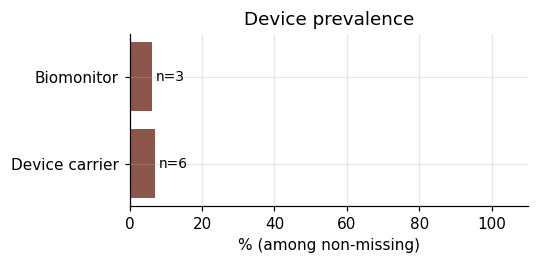

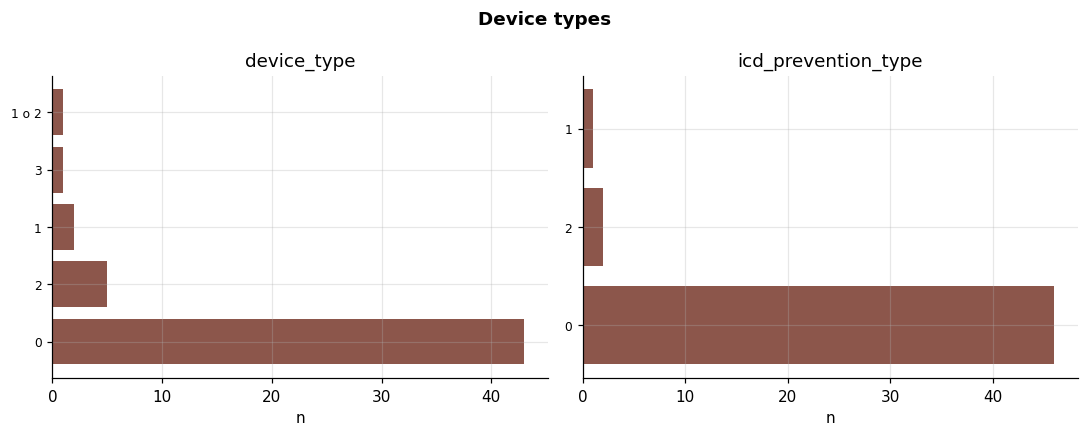

In [23]:
device_bin = [c for c in ['device_carrier', 'biomonitor'] if c in df.columns]
dev_labels = {'device_carrier': 'Device carrier', 'biomonitor': 'Biomonitor'}

if device_bin:
    pct = [(df[c] == 1).sum() / df[c].notna().sum() * 100 for c in device_bin]
    ns  = [int((df[c] == 1).sum()) for c in device_bin]
    fig, ax = plt.subplots(figsize=(5, 2.5))
    bars = ax.barh([dev_labels.get(c, c) for c in device_bin], pct, color=PAL[5])
    for bar, n in zip(bars, ns):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                f'n={n}', va='center', fontsize=9)
    ax.set_xlabel('% (among non-missing)')
    ax.set_xlim(0, 110)
    ax.set_title('Device prevalence')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / '08a_device_prevalence.png', bbox_inches='tight')
    plt.show()

device_cat = [c for c in ['device_type', 'icd_prevention_type'] if c in df.columns]
if device_cat:
    fig, axes = plt.subplots(1, len(device_cat), figsize=(5 * len(device_cat), 4))
    if len(device_cat) == 1:
        axes = [axes]
    for ax, col in zip(axes, device_cat):
        vc = df[col].dropna().astype(str).value_counts().head(8)
        ax.barh(vc.index, vc.values, color=PAL[5])
        ax.set_title(col)
        ax.set_xlabel('n')
        ax.tick_params(axis='y', labelsize=8)
    plt.suptitle('Device types', fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / '08b_device_types.png', bbox_inches='tight')
    plt.show()

## 9 · Arrhythmias

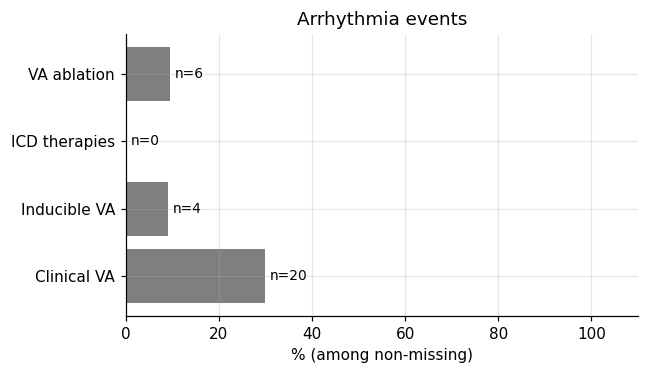

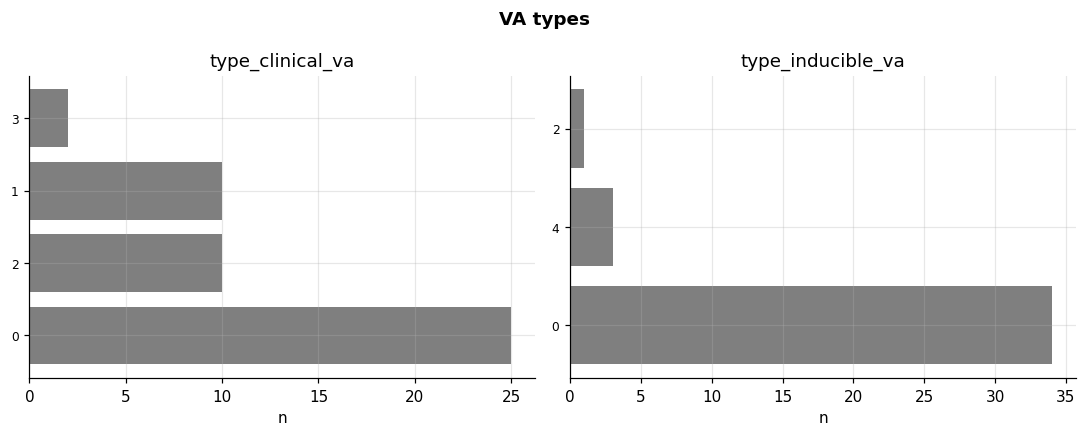

In [24]:
arr_bin = [c for c in ['clinical_va', 'inducible_va', 'icd_therapies', 'va_ablation']
           if c in df.columns]
arr_labels = {
    'clinical_va': 'Clinical VA', 'inducible_va': 'Inducible VA',
    'icd_therapies': 'ICD therapies', 'va_ablation': 'VA ablation',
}
if arr_bin:
    pct = [(df[c] == 1).sum() / df[c].notna().sum() * 100 for c in arr_bin]
    ns  = [int((df[c] == 1).sum()) for c in arr_bin]
    fig, ax = plt.subplots(figsize=(6, 3.5))
    bars = ax.barh([arr_labels.get(c, c) for c in arr_bin], pct, color=PAL[7])
    for bar, n in zip(bars, ns):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                f'n={n}', va='center', fontsize=9)
    ax.set_xlabel('% (among non-missing)')
    ax.set_xlim(0, 110)
    ax.set_title('Arrhythmia events')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / '09a_arrhythmia_prevalence.png', bbox_inches='tight')
    plt.show()

arr_cat = [c for c in ['type_clinical_va', 'type_inducible_va'] if c in df.columns]
if arr_cat:
    fig, axes = plt.subplots(1, len(arr_cat), figsize=(5 * len(arr_cat), 4))
    if len(arr_cat) == 1:
        axes = [axes]
    for ax, col in zip(axes, arr_cat):
        vc = df[col].dropna().astype(str).value_counts().head(8)
        ax.barh(vc.index, vc.values, color=PAL[7])
        ax.set_title(col)
        ax.set_xlabel('n')
        ax.tick_params(axis='y', labelsize=8)
    plt.suptitle('VA types', fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / '09b_va_types.png', bbox_inches='tight')
    plt.show()

## 10 · Medications

Columns store the dose text when prescribed and `0` when not.
A patient is counted as **on medication** when the value is not `0`, `N`, `NO`, or missing.

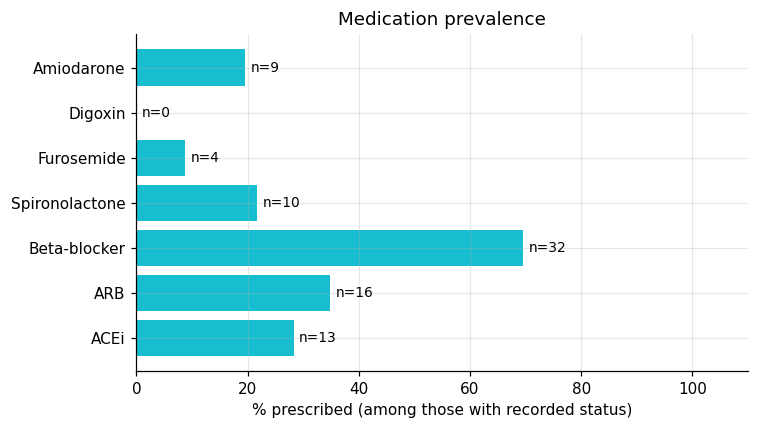

In [25]:
med_cols = [c for c in COLUMN_GROUPS['medications'] if c in df.columns]
med_labels = {
    'med_acei': 'ACEi', 'med_arb': 'ARB', 'med_bb': 'Beta-blocker',
    'med_spiro': 'Spironolactone', 'med_furosemide': 'Furosemide',
    'med_digoxin': 'Digoxin', 'med_amiodarone': 'Amiodarone',
}
NOT_PRESCRIBED = {'0', 'n', 'no', 'false', 'nan'}
if med_cols:
    pct, ns, labels = [], [], []
    for c in med_cols:
        s = df[c].dropna().astype(str).str.strip().str.lower()
        prescribed = (~s.isin(NOT_PRESCRIBED)).sum()
        total = len(s)
        pct.append(prescribed / total * 100 if total > 0 else 0)
        ns.append(int(prescribed))
        labels.append(med_labels.get(c, c))
    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.barh(labels, pct, color=PAL[9])
    for bar, n in zip(bars, ns):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                f'n={n}', va='center', fontsize=9)
    ax.set_xlabel('% prescribed (among those with recorded status)')
    ax.set_xlim(0, 110)
    ax.set_title('Medication prevalence')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / '10_medications.png', bbox_inches='tight')
    plt.show()

## 11 · Outcomes

,event,n,pct
0,death_yn,1,2.325581
1,cardiac_death_yn,0,0.000000
2,arrhythmic_death_yn,0,0.000000
3,followup_va_yn,0,0.000000
4,admission_hf,1,2.439024
5,admission_angina,7,16.666667


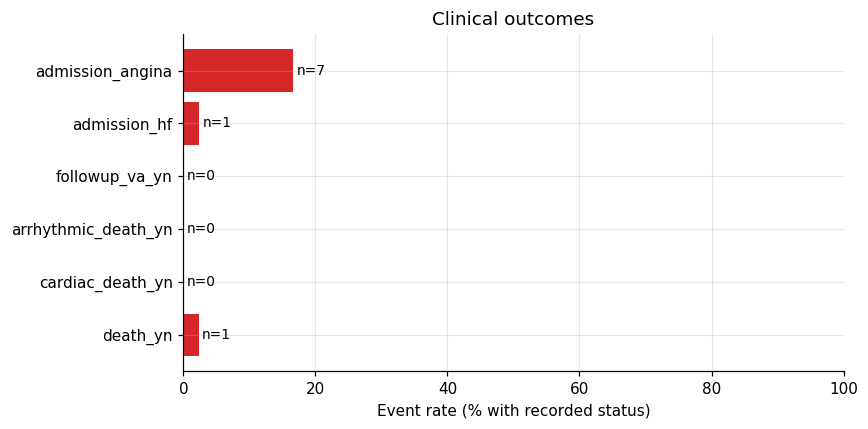

In [26]:
outcome_cols = [c for c in ['death_yn', 'cardiac_death_yn', 'arrhythmic_death_yn',
                             'followup_va_yn', 'admission_hf', 'admission_angina']
                if c in df.columns]
if outcome_cols:
    rates = pd.DataFrame({
        'event': outcome_cols,
        'n':   [int((df[c] == 1).sum()) for c in outcome_cols],
        'pct': [(df[c] == 1).sum() / df[c].notna().sum() * 100 for c in outcome_cols],
    })
    display(rates)
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.barh(rates['event'], rates['pct'], color=PAL[3])
    for i, (n, pct) in enumerate(zip(rates['n'], rates['pct'])):
        ax.text(pct + 0.5, i, f'n={n}', va='center', fontsize=9)
    ax.set_xlabel('Event rate (% with recorded status)')
    ax.set_xlim(0, 100)
    ax.set_title('Clinical outcomes')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / '11a_outcomes.png', bbox_inches='tight')
    plt.show()

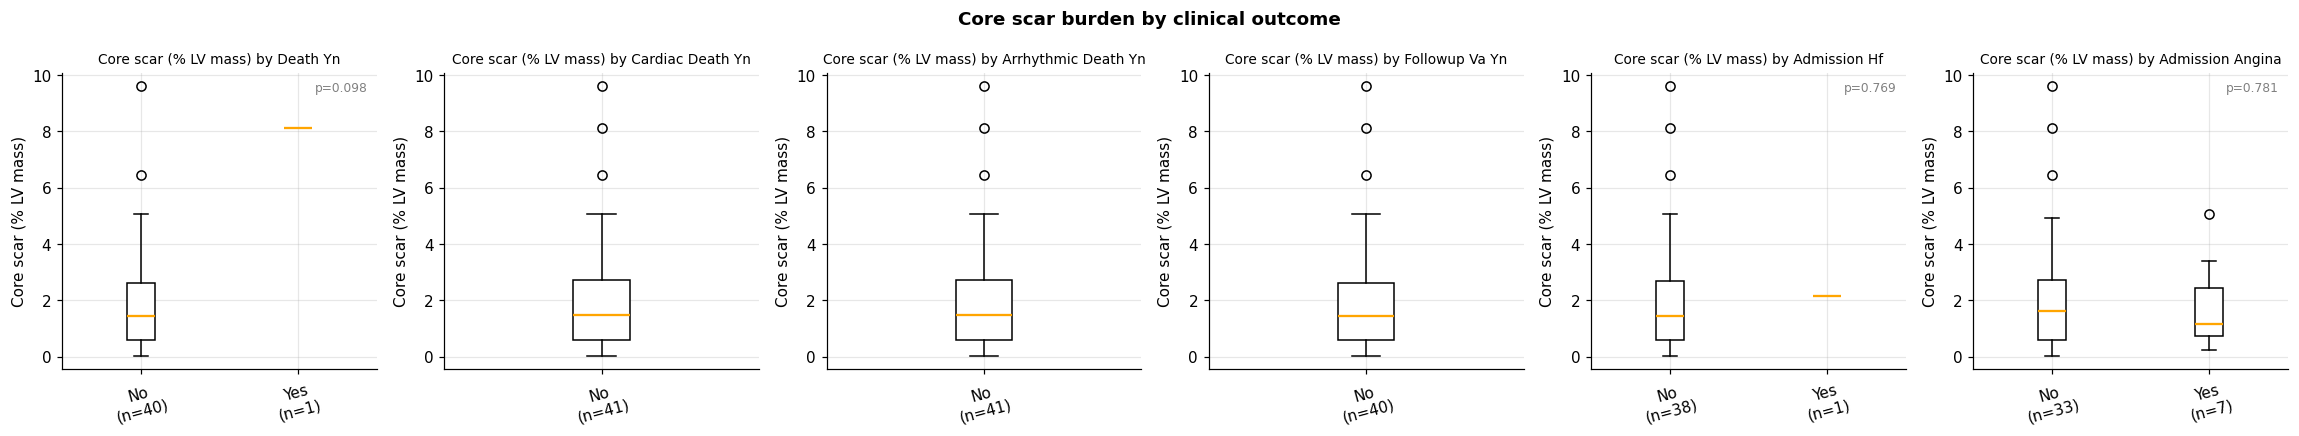

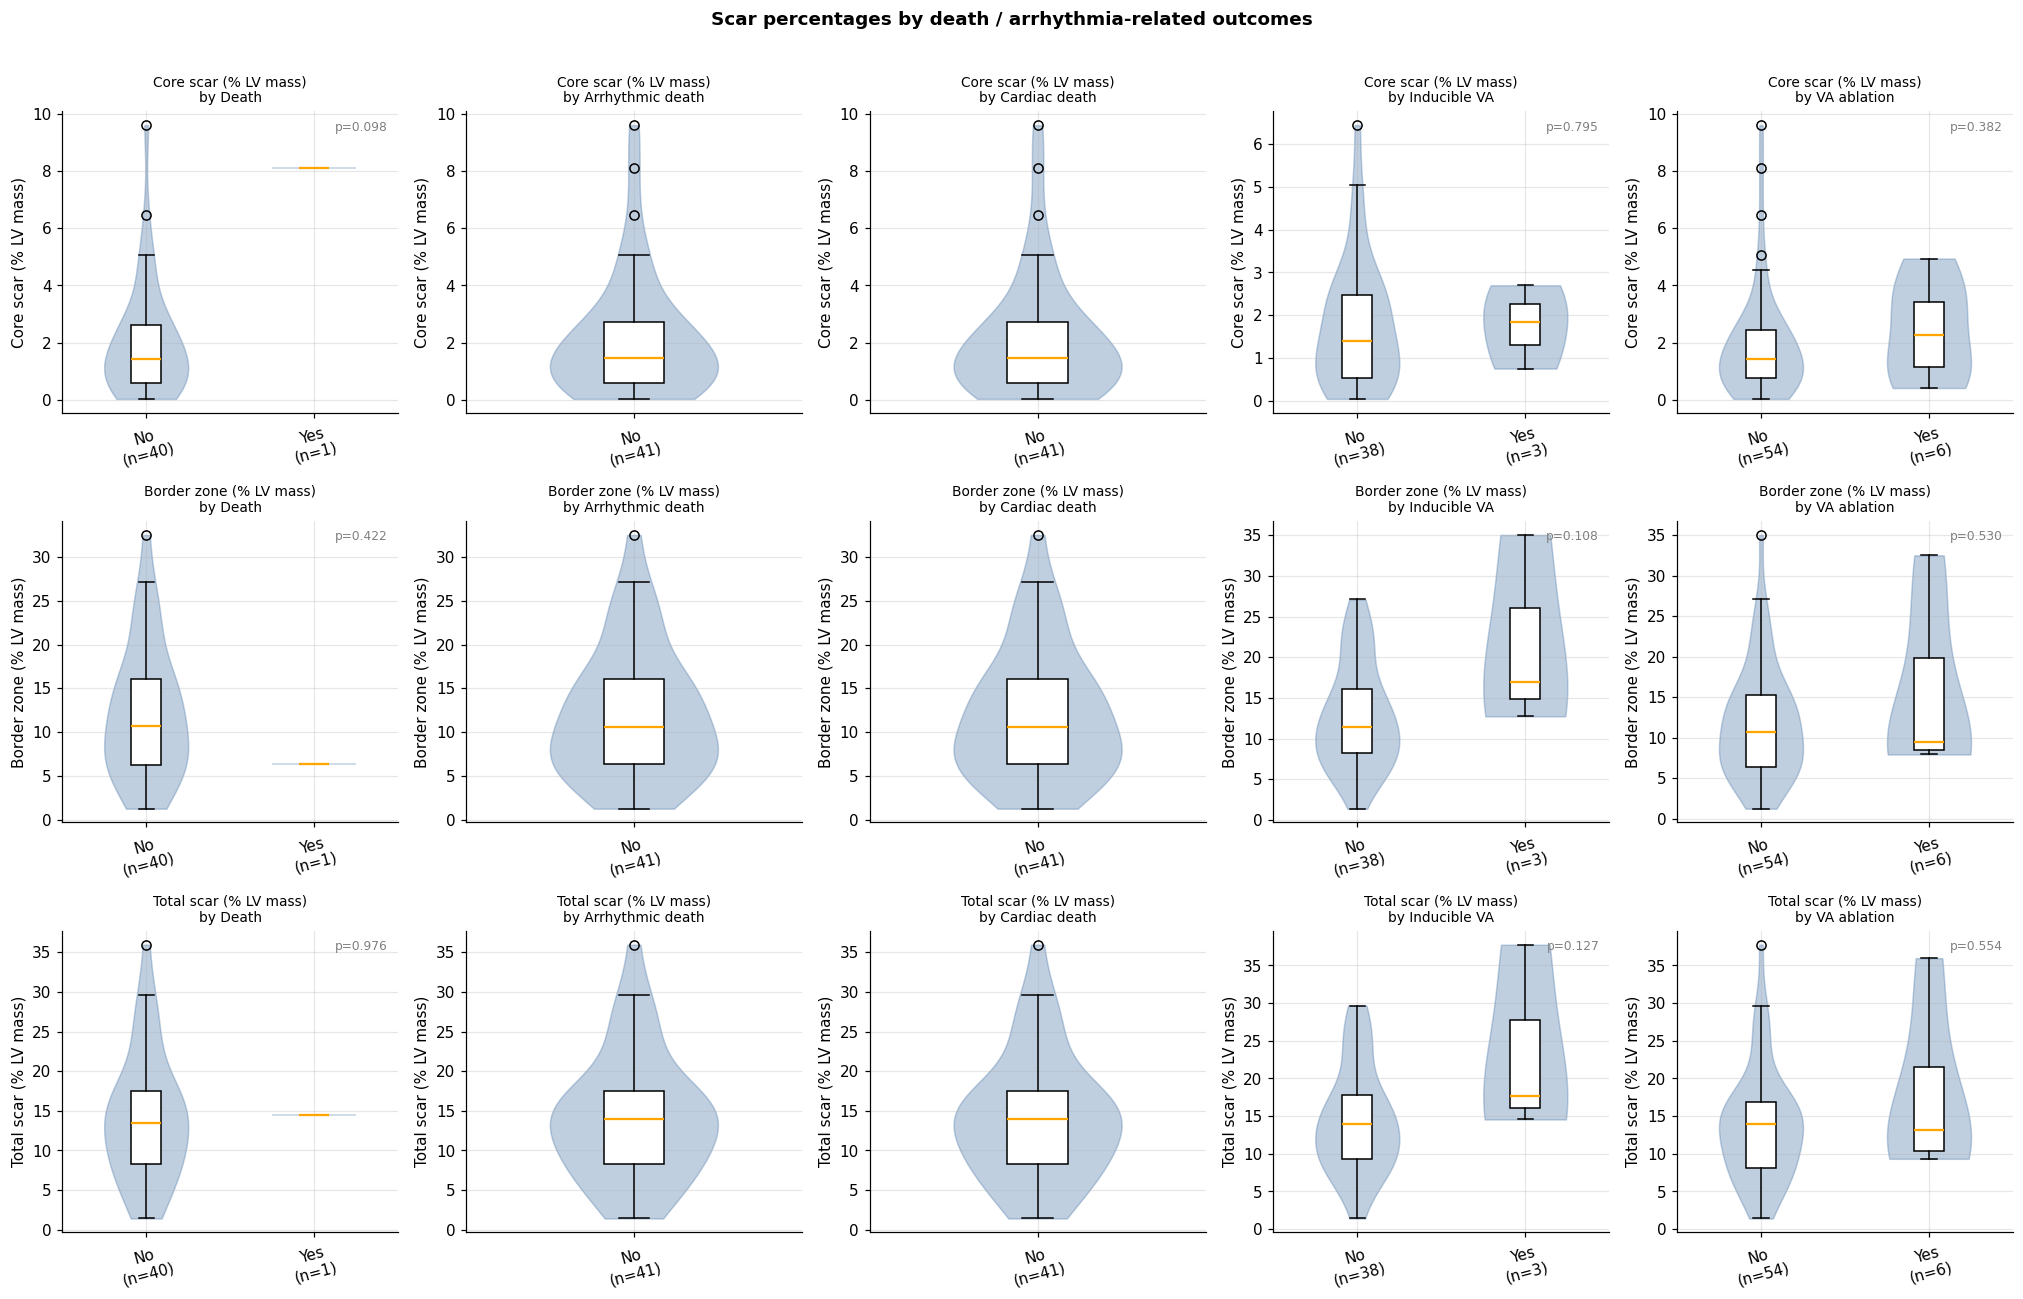

In [27]:
if 'core_pct' in df.columns and outcome_cols:
    fig, axes = plt.subplots(1, len(outcome_cols),
                             figsize=(3.5 * len(outcome_cols), 4))
    if len(outcome_cols) == 1:
        axes = [axes]
    for ax, oc in zip(axes, outcome_cols):
        boxplot_group(df, oc, 'core_pct', labels={0: 'No', 1: 'Yes'}, ax=ax)
    plt.suptitle('Core scar burden by clinical outcome', fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / '11b_scar_by_outcome.png', bbox_inches='tight')
    plt.show()

outcome_focus = [c for c in ['death_yn', 'arrhythmic_death_yn', 'cardiac_death_yn',
                             'inducible_va', 'va_ablation']
                 if c in df.columns]
outcome_focus_labels = {
    'death_yn': 'Death',
    'arrhythmic_death_yn': 'Arrhythmic death',
    'cardiac_death_yn': 'Cardiac death',
    'inducible_va': 'Inducible VA',
    'va_ablation': 'VA ablation',
}
scar_pct_outcomes = [c for c in ['core_pct', 'bz_pct', 'bz_core_pct'] if c in df.columns]

if outcome_focus and scar_pct_outcomes:
    fig, axes = plt.subplots(len(scar_pct_outcomes), len(outcome_focus),
                             figsize=(3.7 * len(outcome_focus), 4.0 * len(scar_pct_outcomes)))
    axes = np.array(axes).reshape(len(scar_pct_outcomes), len(outcome_focus))
    for r, scar_col in enumerate(scar_pct_outcomes):
        for c, outcome_col in enumerate(outcome_focus):
            boxplot_group(
                df, outcome_col, scar_col,
                labels={0: 'No', 1: 'Yes', **({} if outcome_col != 'sex' else {1: 'Male', 2: 'Female'})},
                ax=axes[r, c], violin=True
            )
            axes[r, c].set_title(f'{variable_label(scar_col)}\nby {outcome_focus_labels.get(outcome_col, variable_label(outcome_col))}', fontsize=9)
    plt.suptitle('Scar percentages by death / arrhythmia-related outcomes', fontweight='bold')
    plt.tight_layout(rect=(0, 0, 1, 0.97))
    plt.savefig(RESULTS_DIR / '11c_scar_pct_by_selected_outcomes.png', bbox_inches='tight')
    plt.show()


## 12 · Ring density vs LVEF and clinical outcomes

Ring-zone scar coverage generated by notebook 01 (`per_patient_ring_coverage.csv`) joined
with the clinical registry.  Each ring column is the fraction of that LV zone's surface
covered by core-zone scar:

| Ring | Grid rows | AHA segments |
|------|-----------|--------------|
| apex | 0–15 | 17 |
| apical | 16–31 | 13–16 |
| mid | 32–47 | 7–12 |
| basal | 48–63 | 1–6 |

**Requires notebook 01 to have been run first** to generate `per_patient_ring_coverage.csv`.

In [ ]:
# ── 12a: Load per-patient ring coverage and merge with clinical data ───────────
RING_COV_PATH = RESULTS_DIR / "per_patient_ring_coverage.csv"

if not RING_COV_PATH.exists():
    print(f"File not found: {RING_COV_PATH}")
    print("Run notebook 01 first (section 4f-0) to generate ring coverage data.")
else:
    _ring_cov = pd.read_csv(RING_COV_PATH)
    _ring_cov['patient_id_norm'] = _ring_cov['patient_id'].map(normalize_patient_id)

    _RING_COLS = ['ring_apex_coverage', 'ring_apical_coverage',
                  'ring_mid_coverage',  'ring_basal_coverage']
    _RING_LABELS = {
        'ring_apex_coverage':   'Apex ring coverage',
        'ring_apical_coverage': 'Apical ring coverage',
        'ring_mid_coverage':    'Mid ring coverage',
        'ring_basal_coverage':  'Basal ring coverage',
    }

    _merged12 = df.merge(
        _ring_cov[['patient_id_norm'] + _RING_COLS],
        on='patient_id_norm', how='inner')
    print(f"Merged: {len(_merged12)} patients with ring coverage + clinical data")
    display(_merged12[_RING_COLS].describe().round(4))

    # ── 12b: LVEF vs ring coverage ────────────────────────────────────────────
    if 'lvef_pct' in _merged12.columns:
        _lvef_sub = _merged12[['lvef_pct'] + _RING_COLS].dropna()
        if len(_lvef_sub) >= 5:
            fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
            for ax, rcol in zip(axes, _RING_COLS):
                _x = _lvef_sub[rcol]
                _y = _lvef_sub['lvef_pct']
                ax.scatter(_x, _y, alpha=0.65, s=28, color=HIST_COLOR)
                if float(_x.std()) > 0:
                    _coeffs = np.polyfit(_x, _y, 1)
                    _xs = np.linspace(float(_x.min()), float(_x.max()), 100)
                    ax.plot(_xs, _coeffs[0] * _xs + _coeffs[1],
                            color='orange', linewidth=1.6)
                    _r = float(_x.corr(_y))
                    ax.text(0.03, 0.97, f'r = {_r:.2f}', transform=ax.transAxes,
                            ha='left', va='top', fontsize=9)
                ax.set_xlabel(_RING_LABELS[rcol], fontsize=9)
                ax.set_ylabel('LVEF (%)', fontsize=9)
                ax.set_title(f'LVEF vs {_RING_LABELS[rcol]}', fontsize=9)
            plt.suptitle(
                f'LVEF vs ring-zone scar coverage  (n={len(_lvef_sub)})',
                fontweight='bold')
            plt.tight_layout(rect=(0, 0, 1, 0.95))
            plt.savefig(RESULTS_DIR / '12b_lvef_vs_ring_coverage.png', bbox_inches='tight')
            plt.show()
        else:
            print(f"Only {len(_lvef_sub)} patients have both LVEF and ring coverage — skipping.")
    else:
        print("lvef_pct not in dataset.")

    # ── 12c: Clinical outcomes vs ring coverage ────────────────────────────────
    _OUTCOME_COLS_12 = [c for c in ['clinical_va', 'inducible_va', 'arrhythmic_death_yn',
                                     'death_yn', 'va_ablation'] if c in _merged12.columns]
    _OUTCOME_LABELS_12 = {
        'clinical_va':           'Clinical VA',
        'inducible_va':          'Inducible VA',
        'arrhythmic_death_yn':   'Arrhythmic death',
        'death_yn':              'Death',
        'va_ablation':           'VA ablation',
    }

    if _OUTCOME_COLS_12:
        for rcol in _RING_COLS:
            _sub12 = _merged12[_OUTCOME_COLS_12 + [rcol]].dropna(subset=[rcol])
            if len(_sub12) < 5:
                continue
            fig, axes = plt.subplots(1, len(_OUTCOME_COLS_12),
                                     figsize=(3.8 * len(_OUTCOME_COLS_12), 4.5))
            if len(_OUTCOME_COLS_12) == 1:
                axes = [axes]
            fig.suptitle(f'{_RING_LABELS[rcol]} vs clinical outcomes', fontweight='bold')
            for ax, oc in zip(axes, _OUTCOME_COLS_12):
                _sub2 = _sub12[[oc, rcol]].dropna()
                _g0 = _sub2.loc[_sub2[oc] == 0, rcol].values
                _g1 = _sub2.loc[_sub2[oc] == 1, rcol].values
                ax.boxplot([_g0, _g1],
                           labels=[f'No (n={len(_g0)})', f'Yes (n={len(_g1)})'],
                           patch_artist=True,
                           medianprops=dict(color='orange', linewidth=1.5),
                           boxprops=dict(facecolor='white', edgecolor='black'))
                if min(len(_g0), len(_g1)) >= 3:
                    _, _p = stats.mannwhitneyu(_g0, _g1, alternative='two-sided')
                    ax.text(0.97, 0.97, f'p={_p:.3f}', transform=ax.transAxes,
                            ha='right', va='top', fontsize=8,
                            color='green' if _p < 0.05 else 'grey')
                ax.set_title(_OUTCOME_LABELS_12.get(oc, oc), fontsize=9)
                ax.set_ylabel(_RING_LABELS[rcol], fontsize=8)
            plt.tight_layout(rect=(0, 0, 1, 0.95))
            plt.savefig(RESULTS_DIR / f'12c_outcome_vs_{rcol}.png', bbox_inches='tight')
            plt.show()
    else:
        print("No outcome columns found.")